In [1]:
import numpy as np

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
# sns.set_style('ticks')
# sns.set_context('talk')  # change to 'paper' later.

import scienceplots
plt.style.use('science')

gen_gt_color = '#FC9272'
ip_gt_color = '#1C9099'
ip_gen_color = '#2ca25f'

ticklabelsize = 26
axeslabelsize = 27
titlesize = 30

linewidth = 4

In [2]:
from scipy import stats
from sklearn.metrics import r2_score
from utils import unnormalize_time, unnormalize_mag
from mtan_utils import mean_squared_error
from constants import agn_list, stars_list, sn_list

time_in_hrs = True

In [3]:
def plot_lc(
    df_alerts, name, title_suffix='', fid_column='fid', magpsf_column='magpsf',
    jd_column='jd', sigmapsf_column='sigmapsf', finkclass_column='finkclass',
    objectId_column='objectId', figsize=(15, 6), make_first_time_zero=True,
    annotate_finkclass=False
):
    """Plots photometry for the given name (objectId) from the alerts dataframe.

    Parameters
    ----------
    name: str
        objectID
    """
    # Accumulate all alerts for the provided objectId
    pdf = df_alerts[df_alerts[objectId_column] == name].sort_values(by=jd_column)

    if len(pdf) == 0:
        raise ValueError(f'No alerts exist for objectId = {name}!')

    fig, ax = plt.subplots(figsize=figsize)

    # Colors to plot
    colordic = {1: 'C0', 2: 'C1'}

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    if make_first_time_zero:
        min_t = pdf[jd_column].min()

    for filt in np.unique(pdf[fid_column]):
        # select data from one filter at a time
        maskFilt = pdf[fid_column] == filt

        t = pdf[maskFilt][jd_column] - min_t if make_first_time_zero else pdf[maskFilt][jd_column]

        ax.errorbar(
            t,
            pdf[maskFilt][magpsf_column],
            pdf[maskFilt][sigmapsf_column],
            ls = '', marker='o', color=colordic[filt], label=filtdic[filt]
        )

        ax.errorbar(
            t,
            pdf[maskFilt][magpsf_column],
            pdf[maskFilt][sigmapsf_column],
            ls='', marker='^', color=colordic[filt]
        )

        if (finkclass_column is not None) and (annotate_finkclass):
            _offset_x = (t.max() - t.min()) / 200
            _offset_y = (pdf[maskFilt][magpsf_column].max() - pdf[maskFilt][magpsf_column].min()) / 100
            for x, y, string in zip(t, pdf[maskFilt][magpsf_column], pdf[maskFilt][finkclass_column]):
                ax.text(
                    x+_offset_x, y+_offset_y, string,
                    color=colordic[filt]
                )

    ax.invert_yaxis()
    ax.legend(fontsize=ticklabelsize)
    ax.set_title(f'{pdf[objectId_column].unique()[0]}'+': '+title_suffix, fontsize=titlesize)
    ax.set_xlabel('Modified Julian Date' if not make_first_time_zero else 'time (days)', fontsize=axeslabelsize)
    ax.set_ylabel('Magnitude', fontsize=axeslabelsize)
    ax.tick_params(axis='x', labelsize=ticklabelsize)
    ax.tick_params(axis='y', labelsize=ticklabelsize)
    return ax
    # msg = """
    # - Circles (●) with error bars show valid alerts that pass the Fink quality cuts.
    # - Upper triangles with errors (▲), represent alert measurements that do not satisfy Fink quality cuts, but are nevetheless contained in the history of valid alerts and used by classifiers.
    # - Lower triangles (▽), represent 5-sigma mag limit in difference image based on PSF-fit photometry contained in the history of valid alerts.
    # """
    # print(msg)

def plot_lc_normalized_data(observed_data, observed_mask, observed_tp, title=None):
    """Just like plot_lc() but plots normalized data
    (i.e., after all preprocessing on magnitudes and times),
    just before passing them as input to the model.

    combined_data must be a tuple of (observed_data, observed_mask, time) coming from a
    dataloader (since it must be normalized).

    observed_data shape: [1, lc_length, dim]  # 1 is the batch size.
    observed_mask shape: [1, lc_length, dim]
    observed_tp shape: [1, lc_length, 1]

    Below is an example code to do that:
    ```
    dim = 2
    test_loader = torch.load('test_dataloader.pth')
    batch = next(iter(test_loader))
    data = batch[0]

    # `index` below controls which image in this batch should be shown.
    index = 0
    assert index <= batch_len - 1

    batch_len = data.shape[0]
    observed_data = data[index, :, :dim].cpu().detach().numpy()
    observed_mask = data[index, :, dim:2 * dim].cpu().detach().numpy()
    observed_tp = data[index, :, -1].cpu().detach().numpy()
    ```
    """
    dim = 2
    # Replace values that are unobserved with zero.
    observed_data[observed_mask == 0] = np.nan

    # Colors to plot
    colordic = {1: 'C0', 2: 'C1'}

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    fig, ax = plt.subplots(1, 1, figsize=(15, 6))
    for i in range(dim):
        ax.plot(
            observed_tp.squeeze(), observed_data[:, i],
            ls = '', marker='o', color=colordic[i+1], label=filtdic[i+1]
        )

    for a in ax:
        a.tick_params(axis='x', labelsize=ticklabelsize)
        a.tick_params(axis='y', labelsize=ticklabelsize)

    ax.invert_yaxis()
    ax.legend(fontsize=ticklabelsize)
    ax.set_title(f'{title}', fontsize=titlesize)
    ax.set_xlabel('Normalized time', fontsize=axeslabelsize)
    ax.set_ylabel('Normalized magnitude', fontsize=axeslabelsize)
    plt.show()

def plot_decoded_lc(
    decoded_lcs, key, num_filters=2, objId=None,
    unnormalize_lcs=True, min_time=None, max_time=None,
    min_max_mags=None, prob_plot=True, whichclass=None,
    also_show_sigmapsf=True, fid_column='fid',
    sigmapsf_column='sigmapsf', objectId_column='objectId'
):
    """This function assumes batch size=1 is used while storing the decoded_lcs.
    min_max_mags is a 2D numpy array. Each row contains [object ID, min_mag, max_mag].
    """
    pred_x, observed_data, observed_mask, observed_times = decoded_lcs[key]

    print(pred_x.shape, observed_data.shape, observed_mask.shape, observed_times.shape)
    
    assert np.all(observed_times[:, 0] == observed_times[:, 1])  # Because we simply repeated the dimension in the evaluation_unsupervised.py code.
    observed_times = observed_times[:, 0]
    # Set to NaN to ensure non-essential time values for this lc are not shown.
    observed_times[observed_times == 0.0] = np.nan
    # Recall that we use make_first_time_zero=True in prepare_data (see get_lc), so the first time value will be zero
    # But we don't want that first time value to be set to NaN. So we undo that below.
    observed_times[0] = 0.0

    if unnormalize_lcs:
        if min_max_mags is None:
            raise ValueError(
                "min_max_mags must be provided if unnormalize_lcs is True!"
            )
        if objId is None:
            raise ValueError("objId must be provided if unnormalize_lcs is True!")
        
        # Extract the row corresponding to the min/max of the object ID.
        row = min_max_mags[np.where(min_max_mags[:,0] == objId)].squeeze()

        if min_time is None or max_time is None:
            raise ValueError(
                "min_time and max_time must be provided if unnormalize_lcs is True!"
            )
        
        # Since we normalize times using min/max of whole train data,
        # min_time and max_time must represent that.
        observed_times = unnormalize_time(observed_times, min_time, max_time)
        # Since we normalize mags using min/max of the light curve itself,
        # min_mag and max_mag must represent that.
        observed_data = unnormalize_mag(
            observed_data, observed_mask, float(row[1]), float(row[2])
        )
        # Pass a mask of all ones for prediction because for
        # interpolation all points can be considered observed.
        pred_x = unnormalize_mag(
            pred_x, np.ones_like(observed_mask), float(row[1]), float(row[2])
        )

    c1 = ['#2b8cbe', '#a6bddb']  # dark and then light blue
    c2 = ['#f03b20', '#feb24c']  # dark and then light orange

    colors = [c1, c2]

    fig, ax = plt.subplots(2, 2, figsize=(18, 12))
    plt.subplots_adjust(wspace=0.01, hspace=0.)
    ax[0, 0].sharex(ax[1, 0])
    ax[0, 1].sharex(ax[1, 1])
    fig.suptitle(objId + f' - {whichclass}', fontsize=titlesize)

    if also_show_sigmapsf:
        pdf = df_alerts[df_alerts[objectId_column] == objId].compute()

    for i in range(num_filters):
        obs_to_show = observed_data[:, i]

        # If `unnormalize_mag` was True, unobserved mags would have been
        # set to nan. So instead set them to zero to be able to calculate
        # metrics and not give nan as output.
        obs_to_show[observed_mask[:, i] == 0.0] = 0.

        rmse = np.sqrt(
            mean_squared_error(obs_to_show, pred_x[:, i], observed_mask[:, i])
        )

        # Set unobserved values to NaN so that they don't show up in the plot.
        obs_to_show[observed_mask[:, i] == 0.0] = np.nan

        resid = obs_to_show - pred_x[:, i]
        #resid_without_nan = resid[~np.isnan(resid)]

        # For calculating R2 score:
        # obs_not_nan_mask = ~np.isnan(obs_to_show)
        # r2score = r2_score(obs_to_show[obs_not_nan_mask], pred_x[:, i][obs_not_nan_mask])

        ax[0, i].plot(observed_times/24 if time_in_hrs else observed_times, obs_to_show, ls = '', marker='o', c=colors[i][1], label=r'$m_{\mathrm{obs}}$', markersize=15)
        ax[0, i].plot(observed_times/24 if time_in_hrs else observed_times, pred_x[:, i], c=colors[i][0], label=r'$m_{\mathrm{pred}}$', linewidth=2.5)
        ax[1, i].scatter(observed_times/24 if time_in_hrs else observed_times, resid, c='black', label=r'$m_{\mathrm{obs}} - m_{\mathrm{pred}}$', alpha=0.8, s=300)

        if also_show_sigmapsf:
            maskFilt = pdf[fid_column] == (i+1)
            assert len(pdf[maskFilt]) == observed_mask[:, i].sum()
            avg_sigmapsf = pdf[maskFilt][sigmapsf_column].mean()
            ax[0, i].text(
                0.8, 0.9, r'$\mathrm{RMSE}, \bar{\sigma_{\mathrm{psf}}} = $'+ f'{rmse:.3f}, {avg_sigmapsf:.3f}',
                horizontalalignment='center', verticalalignment='center',
                transform=ax[0, i].transAxes, fontsize=30
            )
        else:
            ax[0, i].text(
                0.8, 0.9, r'$\mathrm{RMSE} = $'+ f'{rmse:.3f}',
                horizontalalignment='center', verticalalignment='center',
                transform=ax[0, i].transAxes, fontsize=30
            )

        if prob_plot:
            ins = ax[1, i].inset_axes([0.05,0.05,0.15,0.15])
    #         ins.hist(resid)
            stats.probplot(resid, plot=ins)
            ins.set_xticks([])
            ins.set_yticks([])
            ins.set_ylabel('')
            ins.set_xlabel('')
            ins.set_title('Probability plot', fontsize=titlesize)
            ins.spines[['right', 'top', 'left']].set_visible(False)

#         ax[1, i].axhline(y=5*stats.median_abs_deviation(resid[~np.isnan(resid)]), linestyle='--', c='black', alpha=0.8)
#         ax[1, i].axhline(y=-5*stats.median_abs_deviation(resid[~np.isnan(resid)]), linestyle='--', c='black', alpha=0.8)
        ax[1, i].axhline(y=0, c='black', alpha=0.8, linestyle='dashed')

        # Set x-axis limits based on its lc only so that we get more detailed understanding of one lc.
        last_non_nan_obs_idx = (~np.isnan(obs_to_show)).cumsum().argmax()
#         ax[0, i].set_xlim([-1, last_non_nan_obs_idx+1])
#         ax[1, i].set_xlim([-1, last_non_nan_obs_idx+1])

        if unnormalize_lcs:
            ax[0, i].set_ylabel(r'$m$', fontsize=axeslabelsize)
            ax[0, i].set_xlabel(r'$t$ (days)', fontsize=axeslabelsize)
            ax[1, i].set_ylabel(r'$m_{\mathrm{obs}} - m_{\mathrm{pred}}$', fontsize=axeslabelsize)
            ax[1, i].set_xlabel(r'$t$ (days)', fontsize=axeslabelsize)
        else:
            ax[0, i].set_ylabel(r'$m_{\mathrm{n}}$', fontsize=axeslabelsize)
            ax[0, i].set_xlabel(r'$t_{\mathrm{n}}$ (days)', fontsize=axeslabelsize)
            ax[1, i].set_ylabel(r'$m_{\mathrm{obs, n}} - m_{\mathrm{pred, n}}$', fontsize=axeslabelsize)
            ax[1, i].set_xlabel(r'$t_{\mathrm{n}}$ (days)', fontsize=axeslabelsize)

#         if i == 0:
#             ax[0, i].set_title(key+r'; $g$ filter', fontsize=titlesize)
#         elif i == 1:
#             ax[0, i].set_title(key+r'; $r$ filter', fontsize=titlesize)

        if i == 0:
            ax[0, i].set_title(r'$g$', fontsize=titlesize)
        elif i == 1:
            ax[0, i].set_title(r'$r$', fontsize=titlesize)

        ax[0, i].invert_yaxis()
        ax[1, i].invert_yaxis()

    for a in ax:
        for b in a:
            b.tick_params(axis='x', labelsize=ticklabelsize, width=2, length=10)
            b.tick_params(axis='y', labelsize=ticklabelsize, width=2, length=10)

    ax[0, 1].legend(fontsize=ticklabelsize, frameon=True)

    plt.tight_layout()
    
    return ax

from utils import normalize_time_values, get_lc

In [4]:
# NOTE: Need to change min_time and max_time if a different dataset is used.

# NOTE: Check value of min_time and max_time when running main_processing.py - the value for the test set must match what's below here.
# max_time: calculated across the test dataset using the SN+AGN data (`ftransfer_ztf_2024-05-27_433174_copy`).
# min_time: calculated across the test dataset. This will be zero since we set first time to zero.
train_min_max_times = np.load('train_min_max_times.npy')
min_time, max_time = train_min_max_times[0], train_min_max_times[1]
min_max_mags = np.load('min_max_mags.npy')

In [5]:
############################################################################################
# Each row in `total_objIds` and `total_common_finkclasses` correspond to the same objectId.
############################################################################################

test_outputs_condensed = np.load('evaluate_test_outputs_condensed.npy')
total_objIds = np.load('total_objIds.npy')
# total_objIds_encoded = np.load('total_objIds_encoded.npy')
total_common_finkclasses = np.load('total_common_finkclasses.npy', allow_pickle=True)
train_objIds = np.load('train_objIds.npy')
val_objIds = np.load('val_objIds.npy')
test_objIds = np.load('evaluate_test_objIds_dataloader.npy')  # it's order matches test_outputs_condensed
test_outputs_condensed.shape, total_objIds.shape, total_common_finkclasses.shape, train_objIds.shape, val_objIds.shape, test_objIds.shape

((3131, 1, 273, 2), (15652,), (15652, 1), (10016,), (2505,), (3131,))

In [6]:
np.any(test_outputs_condensed == -999), np.any(np.isnan(test_outputs_condensed))

(False, True)

In [7]:
import dask.dataframe as dd

df_alerts = dd.read_parquet(
    'alerts_processed_ftransfer_ztf_2025_05_31_430518.parquet',
    columns=[
                'objectId', 'finkclass', 'tnsclass',
                 'fid', 'magpsf', 'sigmapsf', 'jd'
            ]
)
df_alerts.shape

(<dask_expr.expr.Scalar: expr=ReadParquetFSSpec(ed1c53b).size() // 7, dtype=int64>,
 7)

In [8]:
# Read the raw alerts.
# NOTE: This will be a large dataframe depending on how many alerts were used and will require large RAM.
# That's why we use dask to read it here.
df_alerts_raw = dd.read_parquet(
    'ftransfer_ztf_2025-05-31_430518/',
    columns=['objectId', 'finkclass', 'tnsclass']
)

In [9]:
objIds_custom_agn_sn = df_alerts_raw['objectId'].unique()

# Get those alerts having finkclass in agn_list and tnsclass in sn_list at the same time.
# df_alerts_raw_subset = df_alerts_raw[(df_alerts_raw['finkclass'].isin(agn_list)) & (df_alerts_raw['tnsclass'].isin(sn_list))]

print(f'no. of transients in raw set of alerts = {len(objIds_custom_agn_sn)}')

# Get only those transients that are present in the final (processed) alerts dataframe since we only use those.
# objIds_custom_agn_sn = set(objIds_custom_agn_sn).intersection(df_alerts['objectId'].unique())
# print(f'no. of transients after removing those only in the raw alerts (not in the processed alerts)  = {len(objIds_custom_agn_sn)}')
# objIds_custom_agn_sn_final = []
# for o in df_alerts['objectId'].unique():
#     # Get the most common finkclass for all alerts of the current transient.
#     curr_transient_alerts = df_alerts_raw_subset[df_alerts_raw_subset['objectId'] == o]
#     s = curr_transient_alerts.shape
#     print(s[0].compute(), s[1])
#     if (
#         len(
#             curr_transient_alerts[curr_transient_alerts['finkclass'].isin(agn_list)]
#         ) >= 1
#         and
#         len(
#             curr_transient_alerts[curr_transient_alerts['tnsclass'].isin(sn_list)]
#         ) >= 1
#     ):
#         objIds_custom_agn_sn_final.append(o)

no. of transients in raw set of alerts = 51367


In [10]:
test_finkclasses = []
for tobjId in test_objIds:
    idx = np.where(total_objIds == tobjId)[0][0]
#     if tobjId in objIds_custom_agn_sn_final:
#         test_finkclasses.append(np.array(['agn_sn']))
#     else:
    test_finkclasses.append(total_common_finkclasses[idx])

test_finkclasses = np.array(test_finkclasses)

train_finkclasses = []
for tobjId in train_objIds:
    idx = np.where(total_objIds == tobjId)[0][0]
#     if tobjId in objIds_custom_agn_sn_final:
#         train_finkclasses.append(np.array(['agn_sn']))
#     else:
    train_finkclasses.append(total_common_finkclasses[idx])

train_finkclasses = np.array(train_finkclasses)

val_finkclasses = []
for tobjId in val_objIds:
    idx = np.where(total_objIds == tobjId)[0][0]
#     if tobjId in objIds_custom_agn_sn_final:
#         val_finkclasses.append(np.array(['agn_sn']))
#     else:
    val_finkclasses.append(total_common_finkclasses[idx])

val_finkclasses = np.array(val_finkclasses)

In [11]:
len(test_finkclasses), len(train_finkclasses), len(val_finkclasses)

(3131, 10016, 2505)

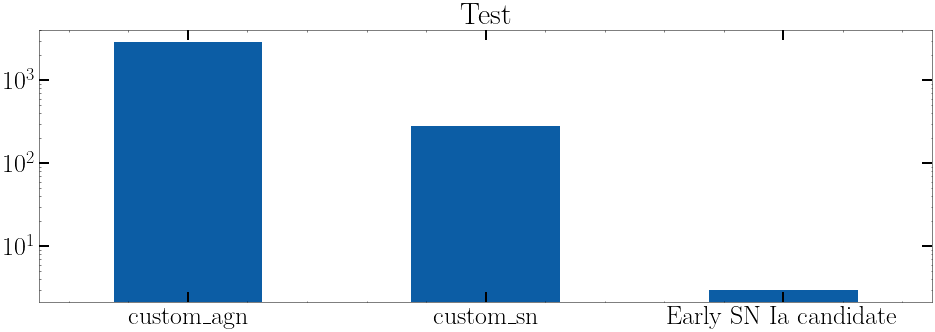

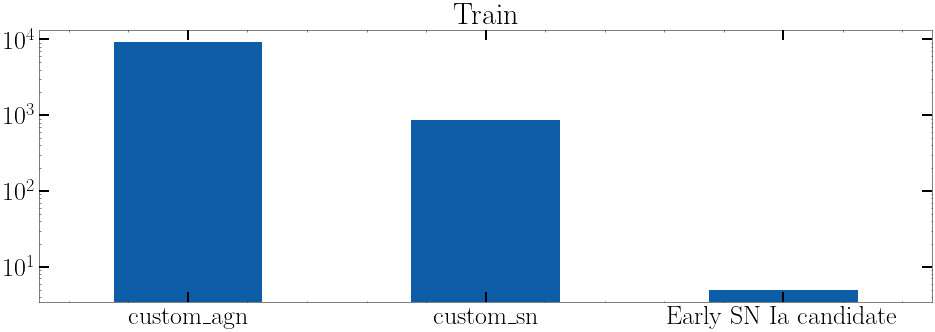

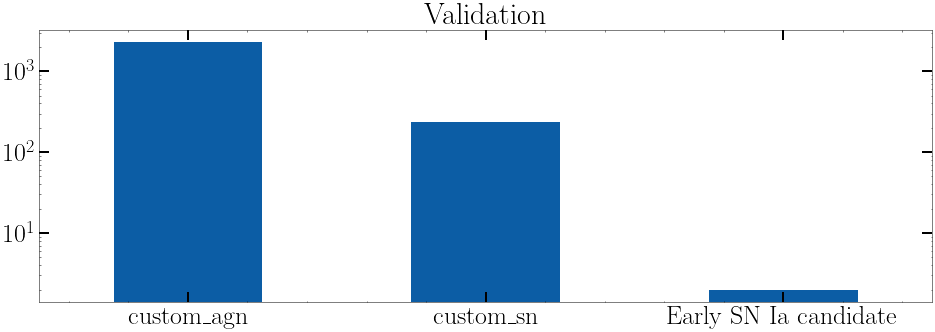

In [12]:
test_finkclasses_flatten = test_finkclasses.flatten()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
pd.Series(
    test_finkclasses_flatten[test_finkclasses_flatten != '0'].flatten()  # !=0 because those were added just for apdding.
).value_counts().plot(kind='bar', ax=ax, rot=0)
ax.set_yscale('log')
ax.set_title('Test', fontsize=titlesize)
ax.tick_params(axis='x', labelsize=ticklabelsize, width=2, length=10)
ax.tick_params(axis='y', labelsize=ticklabelsize, width=2, length=10)
plt.show()

train_finkclasses_flatten = train_finkclasses.flatten()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
pd.Series(
    train_finkclasses_flatten[train_finkclasses_flatten != '0'].flatten()  # !=0 because those were added just for apdding.
).value_counts().plot(kind='bar', ax=ax, rot=0)
ax.set_yscale('log')
ax.set_title('Train', fontsize=titlesize)
ax.tick_params(axis='x', labelsize=ticklabelsize, width=2, length=10)
ax.tick_params(axis='y', labelsize=ticklabelsize, width=2, length=10)
plt.show()

val_finkclasses_flatten = val_finkclasses.flatten()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
pd.Series(
    val_finkclasses_flatten[val_finkclasses_flatten != '0'].flatten()  # !=0 because those were added just for apdding.
).value_counts().plot(kind='bar', ax=ax, rot=0)
ax.set_yscale('log')
ax.set_title('Validation', fontsize=titlesize)
ax.tick_params(axis='x', labelsize=ticklabelsize, width=2, length=10)
ax.tick_params(axis='y', labelsize=ticklabelsize, width=2, length=10)
plt.show()

# 2D Projection of encoded representations

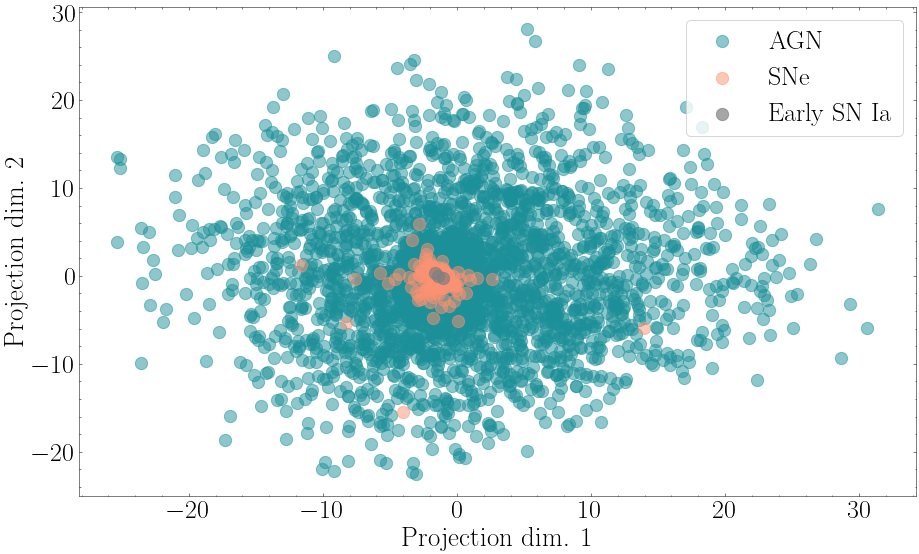

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import umap
from sklearn.manifold import TSNE

# Since test_outputs_condensed is
# (num_test_examples, num_sample, max_num_ref_points_test_set, number_of_filters),
# we are averaging over the num_sample dimension.
test_outputs_condensed_condensed = test_outputs_condensed.mean(1)
# test_outputs_condensed_condensed = test_outputs_condensed_condensed[:, :6]  # Because most light curves have ~<10 datapoints. See the histogram below.
# test_outputs_condensed_condensed = test_outputs_condensed[:, 0, :, :].mean(2)

# Flatten across latent_dim dimension.
test_outputs_condensed_condensed = test_outputs_condensed_condensed.reshape(test_outputs_condensed_condensed.shape[0], -1)

# Each light curve will have different number of query points due to our approach of
# using custom query for each light curve. Thus, we set the values to nan in
# `evaluate_unsupervised.py`. Here we replace them to zero for projection visualization. 
test_outputs_condensed_condensed = np.nan_to_num(test_outputs_condensed_condensed, nan=0.)

agn_indicator = (test_finkclasses == 'custom_agn').astype(int).squeeze()
# stars_indicator = (test_finkclasses == 'custom_stars').astype(int).squeeze()
# simbad_galaxies_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in simbad_galaxies_list]) > 0 else 0, 1, test_finkclasses)
# cataclyv_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in ['CataclyV*']]) > 0 else 0, 1, test_finkclasses)
# tns_tde_indicator = np.apply_along_axis(lambda x: 1 if len([i for i in x if i in ['TNS (TDE)']]) > 0 else 0, 1, test_finkclasses)
sn_indicator = (test_finkclasses == 'custom_sn').astype(int).squeeze()
early_sn1a_indicator = (test_finkclasses == 'Early SN Ia candidate').astype(int).squeeze()

colors = ['#1C9099', '#FC9272', 'gray']

pca = True
umap_use = False
tsne = False

test_outputs_condensed_condensed_scaled = StandardScaler().fit_transform(test_outputs_condensed_condensed)

if pca:
    test_outputs_condensed_condensed_transformed = PCA(n_components=2).fit_transform(test_outputs_condensed_condensed_scaled)
elif umap_use:
    test_outputs_condensed_condensed_transformed = umap.UMAP(random_state=42).fit_transform(test_outputs_condensed_condensed_scaled)
elif tsne:
    test_outputs_condensed_condensed_transformed = TSNE(random_state=42).fit_transform(test_outputs_condensed_condensed_scaled)

fig, ax = plt.subplots(1, 1, figsize=(15, 9))
if sum(agn_indicator) != 0:
    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][agn_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][agn_indicator==1],
        c=colors[0], label='AGN', s=150, alpha=0.5
    )
if sum(sn_indicator != 0):
    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][sn_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][sn_indicator==1],
        c=colors[1], label='SNe', s=150, alpha=0.5
    )
if sum(early_sn1a_indicator != 0):
    ax.scatter(
        test_outputs_condensed_condensed_transformed[:, 0][early_sn1a_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][early_sn1a_indicator==1],
        c=colors[2], label='Early SN Ia', s=150, alpha=0.7
    )
# if sum(stars_indicator) != 0:
#     ax.scatter(
#         test_outputs_condensed_condensed_transformed[:, 0][stars_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][stars_indicator==1],
#         c=colors[1], label='stars_list', s=150, alpha=0.7
#     )

# ax.scatter(
#     test_outputs_condensed_condensed_transformed[:, 0][simbad_galaxies_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][simbad_galaxies_indicator==1],
#     c=colors[2], label='simbad_galaxies_list', s=150, alpha=0.7
# )

# if sum(cataclyv_indicator != 0):
#     ax.scatter(
#         test_outputs_condensed_condensed_transformed[:, 0][cataclyv_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][cataclyv_indicator==1],
#         c=colors[3], label='CataclyV*', s=150, alpha=0.7
#     )
# if sum(tns_tde_indicator != 0):
#     ax.scatter(
#         test_outputs_condensed_condensed_transformed[:, 0][tns_tde_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][tns_tde_indicator==1],
#         c=colors[4], label='TNS (TDE)', s=150, alpha=0.7
#     )

# if sum(agn_sn_indicator != 0):
#     ax.scatter(
#         test_outputs_condensed_condensed_transformed[:, 0][agn_sn_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][agn_sn_indicator==1],
#         c=colors[5], label='SNe', s=150, alpha=0.7
#     )
ax.legend(fontsize=ticklabelsize, frameon=True)
ax.set_xlabel('Projection dim. 1', fontsize=axeslabelsize)
ax.set_ylabel('Projection dim. 2', fontsize=axeslabelsize)
ax.tick_params(axis='x', labelsize=ticklabelsize)
ax.tick_params(axis='y', labelsize=ticklabelsize)

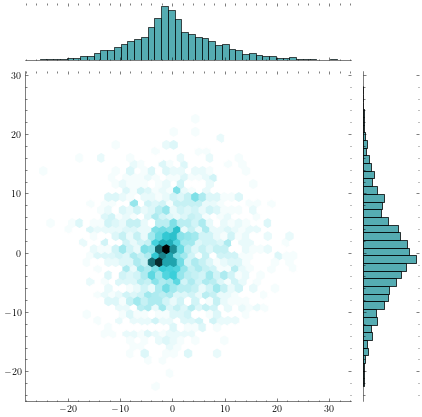

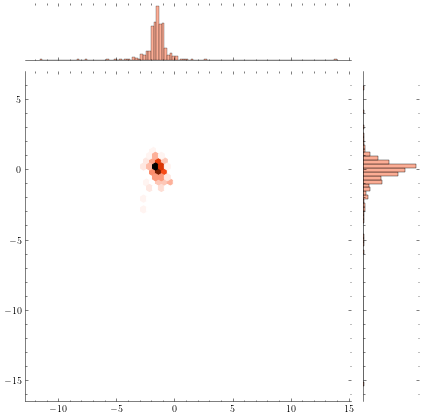

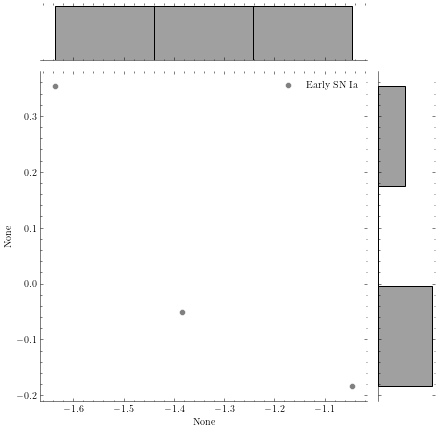

In [14]:
import seaborn as sns

if sum(agn_indicator) != 0:
    sns.jointplot(
        x=test_outputs_condensed_condensed_transformed[:, 0][agn_indicator==1], y=test_outputs_condensed_condensed_transformed[:, 1][agn_indicator==1],
        color=colors[0], label='AGN', kind='hex', mincnt=1
    )
if sum(sn_indicator != 0):
    sns.jointplot(
        x=test_outputs_condensed_condensed_transformed[:, 0][sn_indicator==1], y=test_outputs_condensed_condensed_transformed[:, 1][sn_indicator==1],
        color=colors[1], label='SN', kind='hex', mincnt=1
    )
if sum(early_sn1a_indicator != 0):
    sns.jointplot(
        x=test_outputs_condensed_condensed_transformed[:, 0][early_sn1a_indicator==1], y=test_outputs_condensed_condensed_transformed[:, 1][early_sn1a_indicator==1],
        color=colors[2], label='Early SN Ia'
    )
# if sum(stars_indicator) != 0:
#     ax.scatter(
#         test_outputs_condensed_condensed_transformed[:, 0][stars_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][stars_indicator==1],
#         c=colors[1], label='stars_list', s=150, alpha=0.7
#     )

# ax.scatter(
#     test_outputs_condensed_condensed_transformed[:, 0][simbad_galaxies_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][simbad_galaxies_indicator==1],
#     c=colors[2], label='simbad_galaxies_list', s=150, alpha=0.7
# )

# if sum(cataclyv_indicator != 0):
#     ax.scatter(
#         test_outputs_condensed_condensed_transformed[:, 0][cataclyv_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][cataclyv_indicator==1],
#         c=colors[3], label='CataclyV*', s=150, alpha=0.7
#     )
# if sum(tns_tde_indicator != 0):
#     ax.scatter(
#         test_outputs_condensed_condensed_transformed[:, 0][tns_tde_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][tns_tde_indicator==1],
#         c=colors[4], label='TNS (TDE)', s=150, alpha=0.7
#     )

# if sum(agn_sn_indicator != 0):
#     ax.scatter(
#         test_outputs_condensed_condensed_transformed[:, 0][agn_sn_indicator==1], test_outputs_condensed_condensed_transformed[:, 1][agn_sn_indicator==1],
#         c=colors[5], label='SNe', s=150, alpha=0.7
#     )
# ax.legend(fontsize=ticklabelsize, frameon=True)
# ax.set_xlabel('Projection dim. 1', fontsize=axeslabelsize)
# ax.set_ylabel('Projection dim. 2', fontsize=axeslabelsize)
# ax.tick_params(axis='x', labelsize=ticklabelsize)
# ax.tick_params(axis='y', labelsize=ticklabelsize)

One can visualize light curves at different locations in this projection space, if required.

In [15]:
test_outputs_condensed_condensed.shape

(3131, 546)

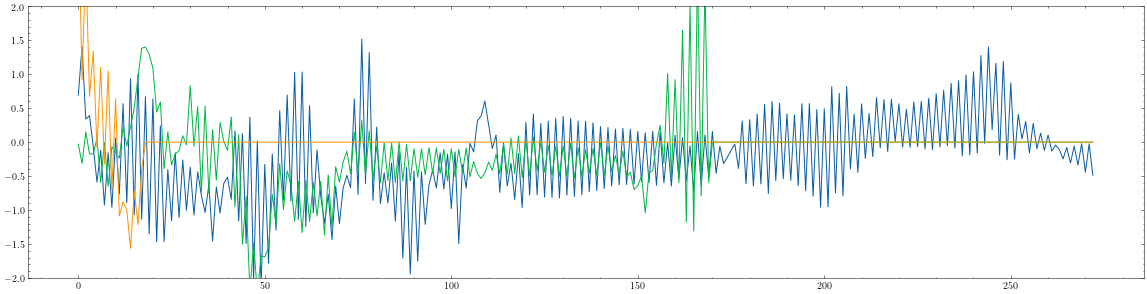

In [16]:
len_one_band_outputs = test_outputs_condensed_condensed.shape[1] // 2
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
for i in range(len(test_outputs_condensed_condensed)):
    ax.plot(test_outputs_condensed_condensed[i][:len_one_band_outputs])
    if i == 2:
        break
ax.set_ylim([-2, +2])
plt.show()

[Text(0, 0, 'AGN'), Text(1, 0, 'SNe'), Text(2, 0, 'Early SN Ia')]

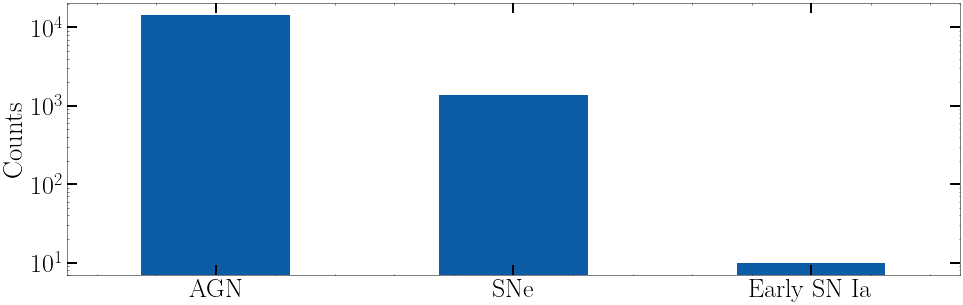

In [17]:
# Plots the distribution of finkclasses across the entire dataset (train+val+test).
total_common_finkclasses_flatten = total_common_finkclasses.flatten()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
pd.Series(
    total_common_finkclasses_flatten[total_common_finkclasses_flatten != '0'].flatten()  # !=0 because those were added just for apdding.
).value_counts().plot(kind='bar', ax=ax, rot=0)
ax.set_yscale('log')
# ax.set_title('total_common_finkclasses')
ax.set_ylabel('Counts', fontsize=axeslabelsize)

ax.tick_params(axis='x', labelsize=ticklabelsize, width=2, length=10)
ax.tick_params(axis='y', labelsize=ticklabelsize, width=2, length=10)
ax.set_xticklabels(['AGN', 'SNe', 'Early SN Ia'])

In [18]:
pd.Series(
    total_common_finkclasses_flatten[total_common_finkclasses_flatten != '0'].flatten()  # !=0 because those were added just for apdding.
).value_counts()

custom_agn               14253
custom_sn                 1389
Early SN Ia candidate       10
Name: count, dtype: int64

Coloring the projection space with light curve properties

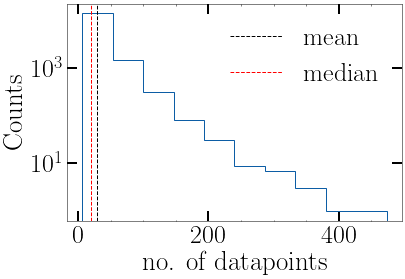

27.979491438793765 19.0


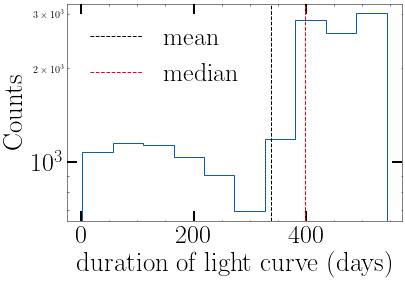

8105.564320222759 9550.914444001392


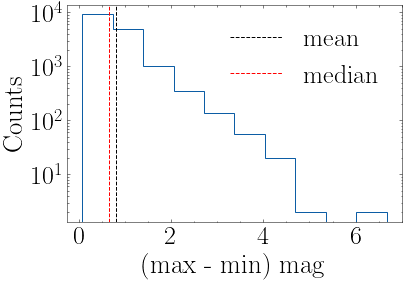

0.8069242129019999 0.6625423431396484 0.47072505950927734 0.5316944966124627


In [19]:
import numpy as np
import pandas as pd
from scipy.stats import iqr

# NOTE: num_datapoints_lcs is the no. of points summed over all filters.
num_datapoints_lcs = np.load('num_datapoints_lcs.npy')

import matplotlib.pyplot as plt
plt.hist(num_datapoints_lcs, histtype='step')
plt.yscale('log')
plt.xlabel('no. of datapoints', fontsize=axeslabelsize)
plt.ylabel('Counts', fontsize=axeslabelsize)
plt.axvline(x=np.mean(num_datapoints_lcs), linestyle='--', c='black', label='mean')
plt.axvline(x=np.median(num_datapoints_lcs), linestyle='--', c='red', label='median')
plt.tick_params(axis='x', labelsize=ticklabelsize, width=2, length=10)
plt.tick_params(axis='y', labelsize=ticklabelsize, width=2, length=10)
plt.legend(fontsize=ticklabelsize)
plt.show()

print(np.mean(num_datapoints_lcs), np.median(num_datapoints_lcs))

duration_lcs = np.load('duration_lcs.npy')
plt.hist(duration_lcs/24, histtype='step')
plt.yscale('log')
plt.xlabel('duration of light curve (days)', fontsize=axeslabelsize)
plt.ylabel('Counts', fontsize=axeslabelsize)
plt.axvline(x=np.mean(duration_lcs/24), linestyle='--', c='black', label='mean')
plt.axvline(x=np.median(duration_lcs/24), linestyle='--', c='red', label='median')
plt.tick_params(axis='x', labelsize=ticklabelsize, width=2, length=10)
plt.tick_params(axis='y', labelsize=ticklabelsize, width=2, length=10)
plt.legend(fontsize=ticklabelsize)
plt.show()

print(np.mean(duration_lcs), np.median(duration_lcs))


min_max_magdiffs = np.load('min_max_magdiffs.npy')

plt.hist(min_max_magdiffs, histtype='step')
plt.yscale('log')
plt.xlabel('(max - min) mag', fontsize=axeslabelsize)
plt.ylabel('Counts', fontsize=axeslabelsize)
plt.axvline(x=np.mean(min_max_magdiffs), linestyle='--', c='black', label='mean')
plt.axvline(x=np.median(min_max_magdiffs), linestyle='--', c='red', label='median')
plt.legend(fontsize=ticklabelsize)
plt.tick_params(axis='x', labelsize=ticklabelsize)
plt.tick_params(axis='y', labelsize=ticklabelsize)
plt.show()

print(np.mean(min_max_magdiffs), np.median(min_max_magdiffs), iqr(min_max_magdiffs), np.std(min_max_magdiffs))

In [20]:
df_alerts_pandas = df_alerts.compute()

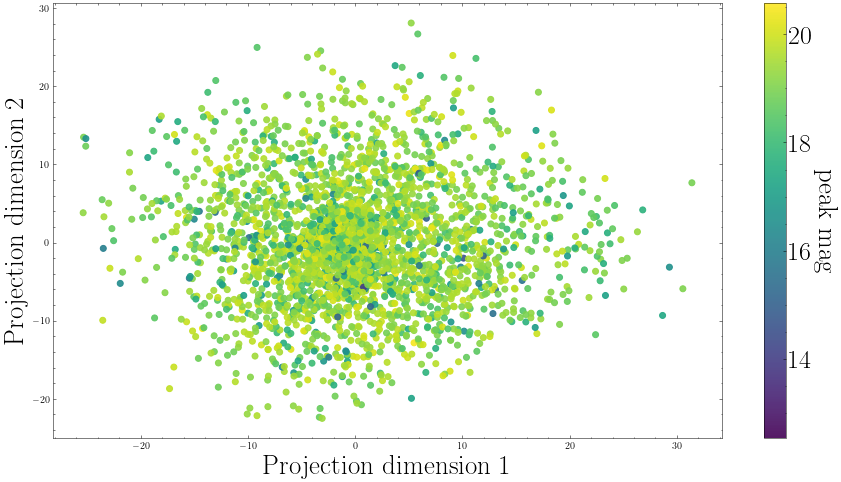

In [21]:
min_mags = []
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts_pandas, oi, time_in_hrs=False)
    obs = data[2]
    obs_mask = data[3]
    min_mags.append(obs[obs_mask == 1].min())

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0],
    test_outputs_condensed_condensed_transformed[:, 1],
    c=min_mags, alpha=0.9
)
ax.set_xlabel('Projection dimension 1', fontsize=axeslabelsize)
ax.set_ylabel('Projection dimension 2', fontsize=axeslabelsize)
cbar = plt.colorbar(sc)
cbar.set_label(
    'peak mag', rotation=270,
    labelpad=25, fontsize=axeslabelsize
)
cbar.ax.tick_params(labelsize=ticklabelsize)

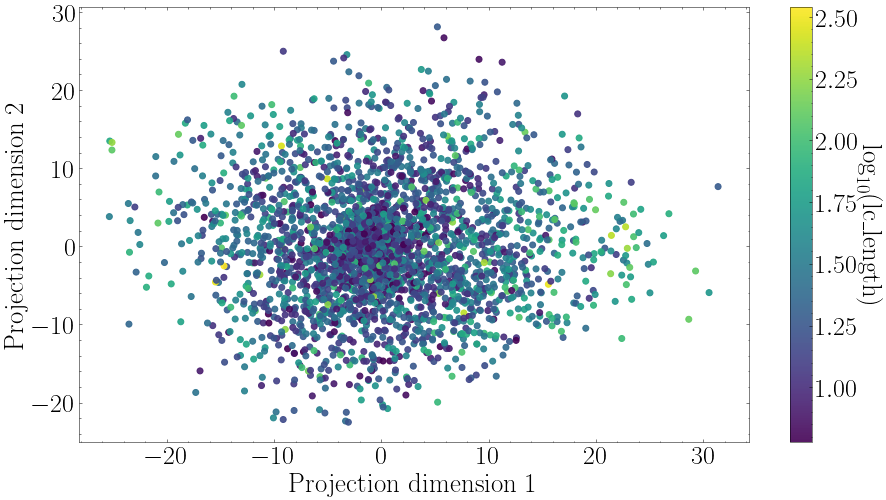

In [22]:
length_lc = []
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts_pandas, oi, time_in_hrs=False)
#     obs = data[2]
    length_lc.append(len(data[1]))

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0],
    test_outputs_condensed_condensed_transformed[:, 1],
    c=np.log10(length_lc), alpha=0.9
)
cbar = plt.colorbar(sc)
ax.set_xlabel('Projection dimension 1', fontsize=axeslabelsize)
ax.set_ylabel('Projection dimension 2', fontsize=axeslabelsize)
ax.tick_params(axis='x', labelsize=ticklabelsize)
ax.tick_params(axis='y', labelsize=ticklabelsize)
cbar.ax.set_ylabel(
    '$\log_{10}(\mathrm{lc\_length})$', rotation=270,
    labelpad=25, fontsize=axeslabelsize
)
cbar.ax.tick_params(labelsize=ticklabelsize)

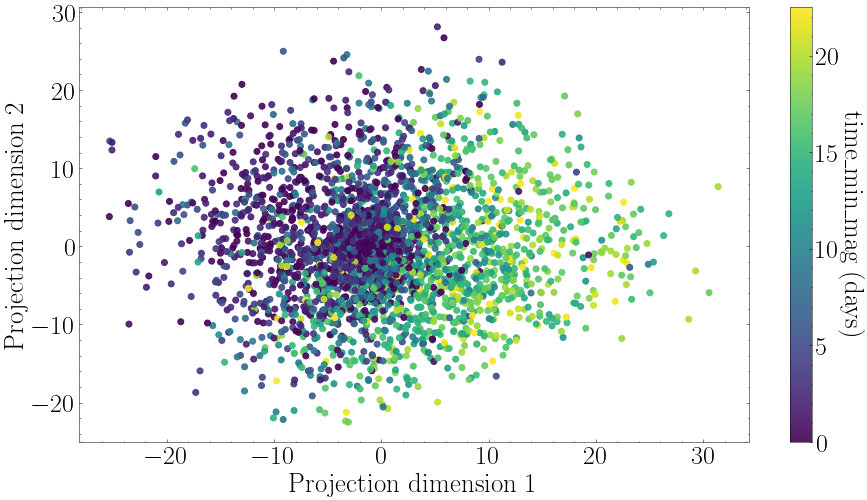

In [23]:
time_min_mag = []
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts_pandas, oi, time_in_hrs=False)
    obs = data[2]
    t = data[1]
    obs = np.where(obs != 0, obs, np.inf)
    tmm = t[np.where(obs == obs.min())[0]]
    time_min_mag.append(tmm/24 if time_in_hrs else tmm)

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0],
    test_outputs_condensed_condensed_transformed[:, 1],
    c=time_min_mag, alpha=0.9
)
cbar = plt.colorbar(sc)
ax.set_xlabel('Projection dimension 1', fontsize=axeslabelsize)
ax.set_ylabel('Projection dimension 2', fontsize=axeslabelsize)
ax.tick_params(axis='x', labelsize=ticklabelsize)
ax.tick_params(axis='y', labelsize=ticklabelsize)
cbar.ax.set_ylabel(
    'time_min_mag (days)', rotation=270,
    labelpad=25, fontsize=axeslabelsize
)
cbar.ax.tick_params(labelsize=ticklabelsize)

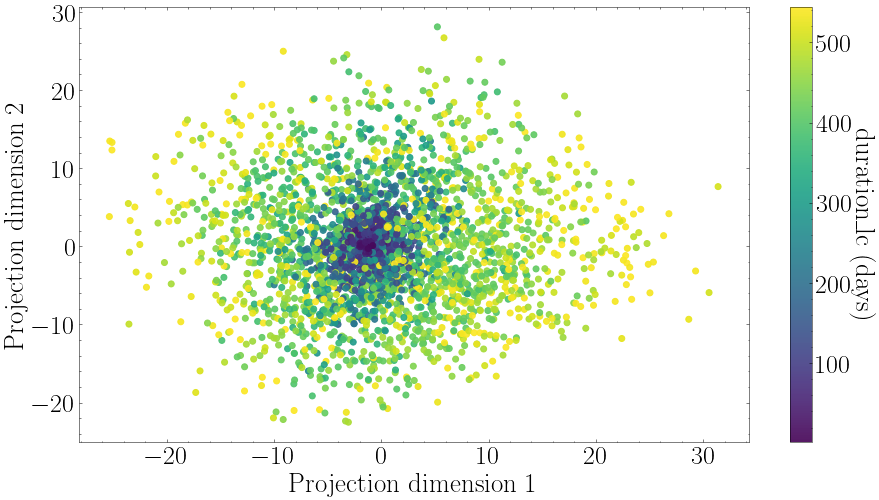

In [24]:
dur = []
for i, oi in enumerate(test_objIds):
    data = get_lc(df_alerts_pandas, oi, time_in_hrs=False)
    t = data[1]
    dur.append(t[-1] - t[0])

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0],
    test_outputs_condensed_condensed_transformed[:, 1],
    c=dur, alpha=0.9
)
cbar = plt.colorbar(sc)
ax.set_xlabel('Projection dimension 1', fontsize=axeslabelsize)
ax.set_ylabel('Projection dimension 2', fontsize=axeslabelsize)
ax.tick_params(axis='x', labelsize=ticklabelsize)
ax.tick_params(axis='y', labelsize=ticklabelsize)
cbar.ax.set_ylabel(
    'duration_lc (days)', rotation=270,
    labelpad=25, fontsize=axeslabelsize
)
cbar.ax.tick_params(labelsize=ticklabelsize)

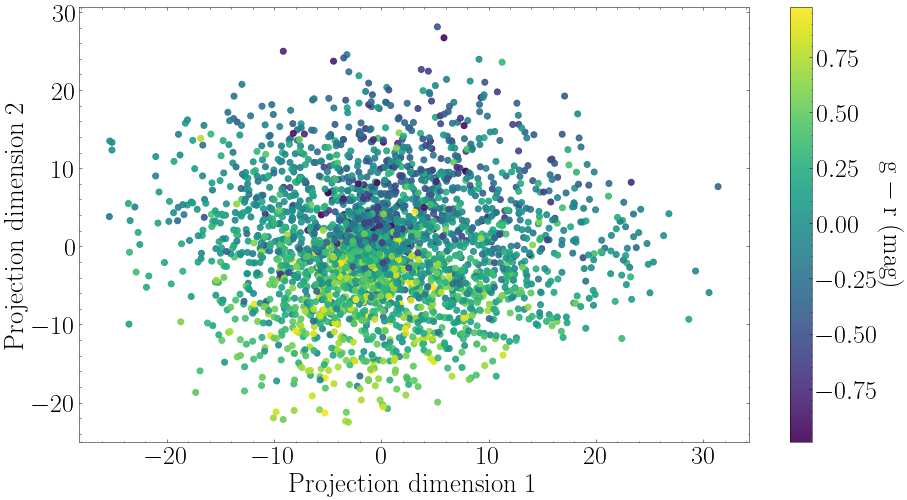

In [25]:
decoded_lcs_test = np.load('evaluate_test_decoded_lcs.npz')
decoded_lcs_test_keys = list(decoded_lcs_test.keys())
mean_colors = []
for key in decoded_lcs_test_keys:
    decoded_lc_test = decoded_lcs_test[key]
    decoded_lc_test_pred = decoded_lc_test[0]
    mean_color = (decoded_lc_test_pred[:, 0] - decoded_lc_test_pred[:, 1]).mean()
    mean_colors.append(mean_color)

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
sc = ax.scatter(
    test_outputs_condensed_condensed_transformed[:, 0],
    test_outputs_condensed_condensed_transformed[:, 1],
    c=mean_colors, alpha=0.9
)
cbar = plt.colorbar(sc)
ax.set_xlabel('Projection dimension 1', fontsize=axeslabelsize)
ax.set_ylabel('Projection dimension 2', fontsize=axeslabelsize)
ax.tick_params(axis='x', labelsize=ticklabelsize)
ax.tick_params(axis='y', labelsize=ticklabelsize)
cbar.ax.set_ylabel(
    r'$\mathrm{g - r}$ (mag)', rotation=270,
    labelpad=25, fontsize=axeslabelsize
)
cbar.ax.tick_params(labelsize=ticklabelsize)

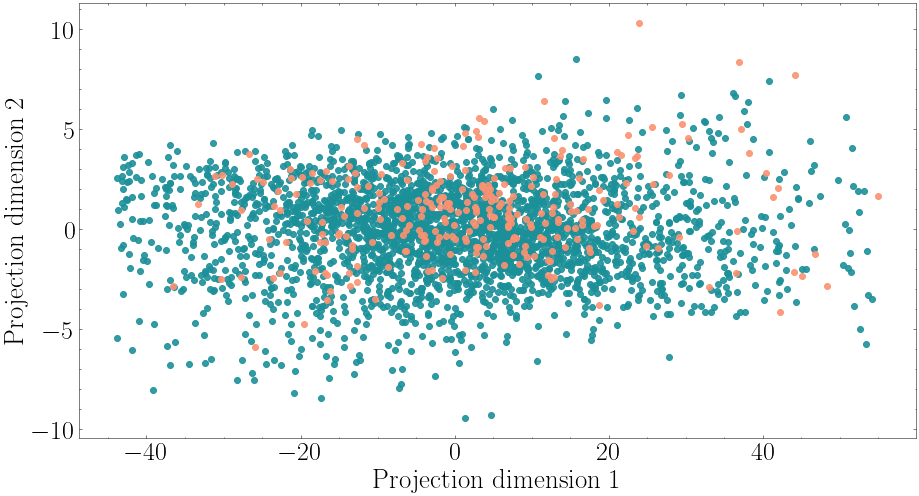

In [26]:
decoded_lcs_test = np.load('evaluate_test_decoded_lcs.npz')
decoded_lcs_test_keys = list(decoded_lcs_test.keys())
lc_colors = []
for key in decoded_lcs_test_keys:
    decoded_lc_test = decoded_lcs_test[key]
    decoded_lc_test_pred = decoded_lc_test[0]
    lc_color = decoded_lc_test_pred[:, 0] - decoded_lc_test_pred[:, 1]
    lc_colors.append(lc_color)

lc_colors = np.vstack(lc_colors)

lc_colors_scaled = StandardScaler().fit_transform(lc_colors)
lc_colors_transformed = PCA(n_components=2).fit_transform(lc_colors_scaled)

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
ax.scatter(
    lc_colors_transformed[:, 0][agn_indicator==1],
    lc_colors_transformed[:, 1][agn_indicator==1],
    alpha=0.9, color=colors[0]
)
ax.scatter(
    lc_colors_transformed[:, 0][sn_indicator==1],
    lc_colors_transformed[:, 1][sn_indicator==1],
    alpha=0.9, color=colors[1]
)
ax.set_xlabel('Projection dimension 1', fontsize=axeslabelsize)
ax.set_ylabel('Projection dimension 2', fontsize=axeslabelsize)
ax.tick_params(axis='x', labelsize=ticklabelsize)
ax.tick_params(axis='y', labelsize=ticklabelsize)

# Similarity search using encoded representations

In [27]:
show_decoded_lcs_along_with_sim_search = True

In [28]:
test_outputs_condensed.shape

(3131, 1, 273, 2)

In [29]:
if show_decoded_lcs_along_with_sim_search:
    decoded_lcs_test = np.load('evaluate_test_decoded_lcs.npz')
    decoded_lcs_val = np.load('evaluate_val_decoded_lcs.npz')
    decoded_lcs_train = np.load('evaluate_train_decoded_lcs.npz')
    dlte = list(decoded_lcs_test.keys())
    dlv = list(decoded_lcs_val.keys())
    dltr = list(decoded_lcs_train.keys())
    dltr_v_te = np.concatenate([dltr, dlv, dlte])

In [30]:
# Redefine plot_lc. This is ONLY done because we want to look at the query and the closest lc side by side.
# So here we pass an axes as input (which means fig needs to be created beforehand).
# Some motivation from here: https://stackoverflow.com/a/66371682

def plot_lc_ax_visualize(
    df_alerts, name, title_suffix='', fid_column='fid', magpsf_column='magpsf',
    jd_column='jd', sigmapsf_column='sigmapsf', finkclass_column='finkclass',
    objectId_column='objectId', ax=None, annotate_finkclass=False
):
    """Plots photometry for the given name (objectId) from the alerts dataframe.

    Parameters
    ----------
    name: str
        objectID
    """
    if ax is None:
        ax = plt.gca()

    # Accumulate all alerts for the provided objectId
    pdf = df_alerts[df_alerts[objectId_column] == name].sort_values(
        by=jd_column
    )

    if len(pdf) == 0:
        raise ValueError(f'No alerts exist for objectId = {name}!')

    # Colors to plot
    colordic = {1: 'C0', 2: 'C1'}

    # Labels of ZTF filters
    filtdic = {1: 'g', 2: 'r'}

    for filt in np.unique(pdf[fid_column]):
        # select data from one filter at a time
        maskFilt = pdf[fid_column] == filt

        times = pdf[maskFilt][jd_column] - pdf[maskFilt][jd_column].min()

        ax.errorbar(
            times,
            pdf[maskFilt][magpsf_column],
            pdf[maskFilt][sigmapsf_column],
            ls = '', marker='o', color=colordic[filt], label=filtdic[filt]
        )

        ax.errorbar(
            times,
            pdf[maskFilt][magpsf_column],
            pdf[maskFilt][sigmapsf_column],
            ls='', marker='^', color=colordic[filt]
        )

        if (finkclass_column is not None) and (annotate_finkclass):
            _offset_x = (times.max() - times.min()) / 200
            _offset_y = (pdf[maskFilt][magpsf_column].max() - pdf[maskFilt][magpsf_column].min()) / 100
            for x, y, string in zip(times, pdf[maskFilt][magpsf_column], pdf[maskFilt][finkclass_column]):
                ax.text(
                    x+_offset_x, y+_offset_y, string,
                    color=colordic[filt]
                )

    ax.invert_yaxis()
    ax.legend(fontsize=ticklabelsize)
    assert len(pdf[objectId_column].unique()) == 1
    ax.set_title(f'{pdf[objectId_column].unique()[0]}'+': '+title_suffix, fontsize=titlesize)
    ax.set_xlabel('time (days)', fontsize=axeslabelsize)
    ax.set_ylabel('mag', fontsize=axeslabelsize)

    ax.tick_params(axis='x', labelsize=ticklabelsize, width=2, length=10)
    ax.tick_params(axis='y', labelsize=ticklabelsize, width=2, length=10)
    return ax

See [this link](https://aws.plainenglish.io/unlocking-faiss-for-efficient-search-vector-indexing-and-ann-with-serverless-architecture-5b2b59ead20f) for `faiss` usage, for example.

In [31]:
def pad_and_concat(array_list, pad_value=0.0):
    # Find maximum length across dim=2
    # this should be the `max_num_ref_points_dataset` dimension
    max_len = max(arr.shape[2] for arr in array_list)

    # Pad each tensor along dim=2
    padded = []
    for arr in array_list:
        pad_width = [(0, 0)] * arr.ndim
        pad_width[2] = (0, max_len - arr.shape[2])  # pad dim=1 at the end
        padded_arr = np.pad(arr, pad_width, mode='constant', constant_values=pad_value)
        padded.append(padded_arr)
    
    return np.concatenate(padded, axis=0)

In [32]:
train_objIds_dataloader = np.load('evaluate_train_objIds_dataloader.npy')
val_objIds_dataloader = np.load('evaluate_val_objIds_dataloader.npy')
test_objIds_dataloader = np.load('evaluate_test_objIds_dataloader.npy')

# NOTE: The order (train first, then val, and then test),
# must match the order used in `outputs` in the below cell.
objIds_dataloader = np.concatenate([train_objIds_dataloader, val_objIds_dataloader, test_objIds_dataloader])

In [33]:
## Requires `pip install faiss-cpu` ##

import numpy as np
import pandas as pd 
import faiss

train_outputs_condensed = np.load('evaluate_train_outputs_condensed.npy')
val_outputs_condensed = np.load('evaluate_val_outputs_condensed.npy')
test_outputs_condensed = np.load('evaluate_test_outputs_condensed.npy')

# Each light curve will have different number of query points due to our approach of
# using custom query for each light curve. Thus, we set the values to nan in
# `evaluate_unsupervised.py`. Here we replace them to zero to make similarity search work.
test_outputs_condensed = np.nan_to_num(test_outputs_condensed, nan=0.)
val_outputs_condensed = np.nan_to_num(val_outputs_condensed, nan=0.)
train_outputs_condensed = np.nan_to_num(train_outputs_condensed, nan=0.)

num_test_examples = len(test_outputs_condensed)
outputs = [train_outputs_condensed, val_outputs_condensed, test_outputs_condensed]
outputs = pad_and_concat(outputs, pad_value=0.)
print(outputs.shape, train_outputs_condensed.shape, val_outputs_condensed.shape, test_outputs_condensed.shape)

assert np.all(val_objIds_dataloader == val_objIds)
assert np.all(test_objIds_dataloader == test_objIds)
assert np.all(train_objIds_dataloader == train_objIds)

# Average across the `num_sample` dimension. Has no effect if num_sample=1.
outputs = outputs.mean(1)
outputs = outputs.reshape(outputs.shape[0], -1)
print(outputs.shape)

# processed_outputs = []
# for o in outputs:
#     # `o` is of shape:
#     # (num_examples_dataset, num_sample, max_num_ref_points_dataset, number_of_filters)

#     # Average across the `num_sample` dimension. Has no effect if num_sample=1.
#     o = o.mean(1)
#     # Flatten across the `number_of_filters` dimension.
#     # Below idea of flattening came from:
#     # https://ai.stackexchange.com/questions/37233/similarities-between-2d-vectors-to-flatten-or-to-not
#     o = o.reshape(o.shape[0], o.shape[1], -1)
#     processed_outputs.append(o)

# No. of max reference points in the combined dataset
vector_dimension = outputs.shape[1]
                                 
faiss.normalize_L2(outputs)
# Note that `IndexFlatIP` in itself only performs the inner dot product.
# This is cosine similarity only because we normalize the vectors in the previous line.
# Cosine sim = inner product on normalized vectors.
index = faiss.IndexFlatIP(vector_dimension)
index.add(outputs)

(15652, 1, 273, 2) (10016, 1, 273, 2) (2505, 1, 272, 2) (3131, 1, 273, 2)
(15652, 546)


In [34]:
outputs.shape

(15652, 546)

In [35]:
train_min_max_times = np.load('train_min_max_times.npy')
min_time, max_time = train_min_max_times[0], train_min_max_times[1]

In [36]:
import time

k = 5  # How many similar examples to return.
t = time.time()
# NOTE: No need to normalize query here because `outputs`
# was already normalized when creating the index above.
similarities, similarities_ids = index.search(outputs, k)
print(f'time required (ms): {((time.time() - t)*1e3):.1f}, for {len(similarities)} vectors')

similarities = np.clip(similarities, 0, 1)

results = pd.DataFrame(
    np.hstack(
        (similarities, similarities_ids)
    )
)
sim_columns = [
        f'sim_{i}' for i in range(similarities.shape[1])
    ]
sim_id_columns = [
        f'sim_id_{i}' for i in range(similarities_ids.shape[1])
    ]
results.columns = sim_columns + sim_id_columns
for col in sim_id_columns:
    results[col] = results[col].astype('int') 
results.shape

time required (ms): 4091.2, for 15652 vectors


(15652, 10)

In [37]:
results.head()

,sim_0,sim_1,sim_2,sim_3,sim_4,sim_id_0,sim_id_1,sim_id_2,sim_id_3,sim_id_4
0,1.0,0.633250,0.627859,0.618617,0.592703,0,5103,5462,14350,2913
1,1.0,0.542219,0.528257,0.520153,0.494574,1,6772,7675,9552,3506
2,1.0,0.780426,0.765992,0.763197,0.748198,2,12332,8043,2408,5628
3,1.0,0.677740,0.667122,0.658210,0.631065,3,8275,6508,165,10545
4,1.0,0.859588,0.842123,0.836784,0.827932,4,588,11301,11086,8228


(347, 2) (347, 2) (347, 2) (347, 2)


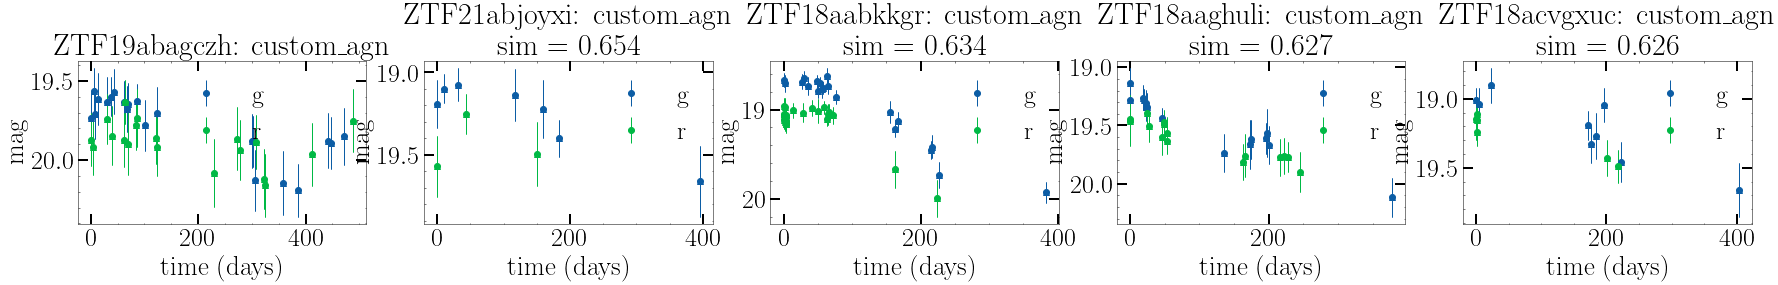

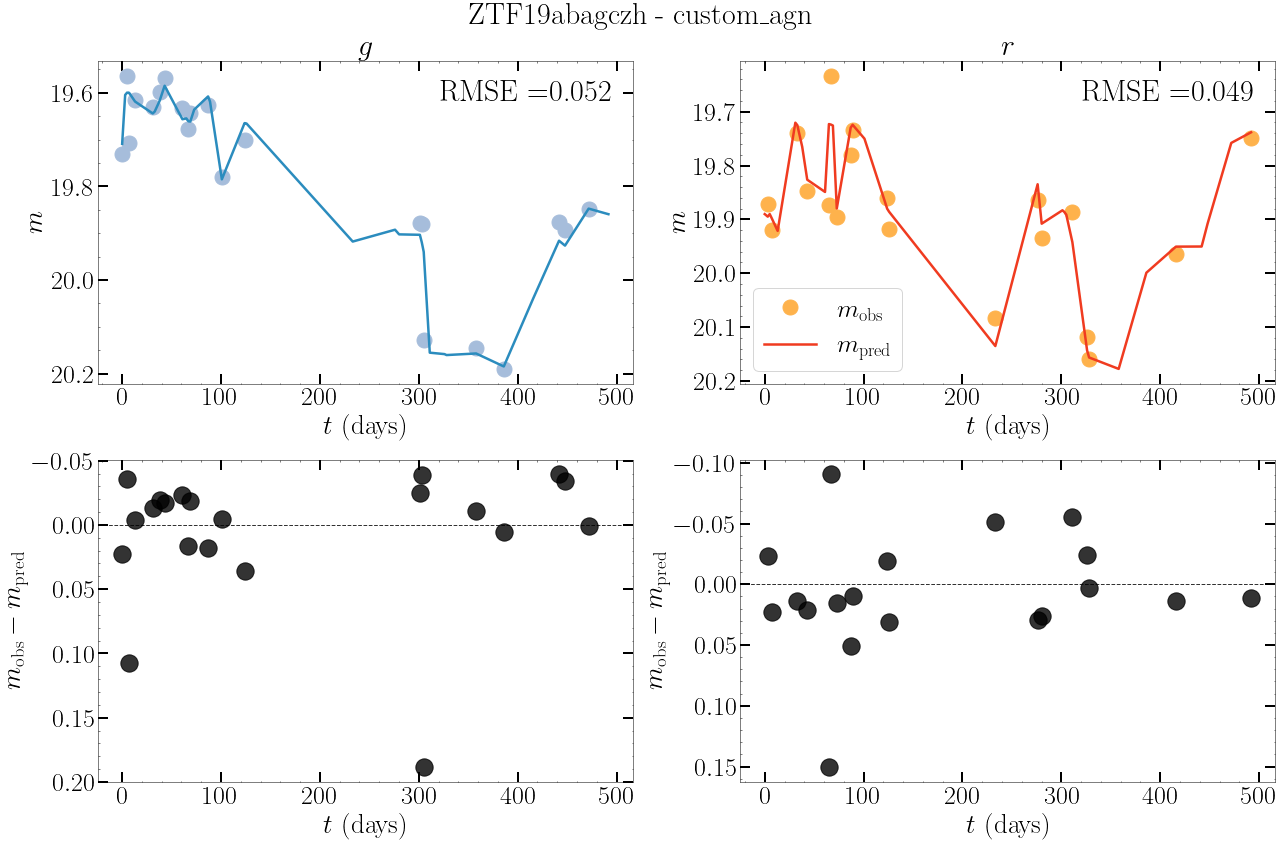

(474, 2) (474, 2) (474, 2) (474, 2)


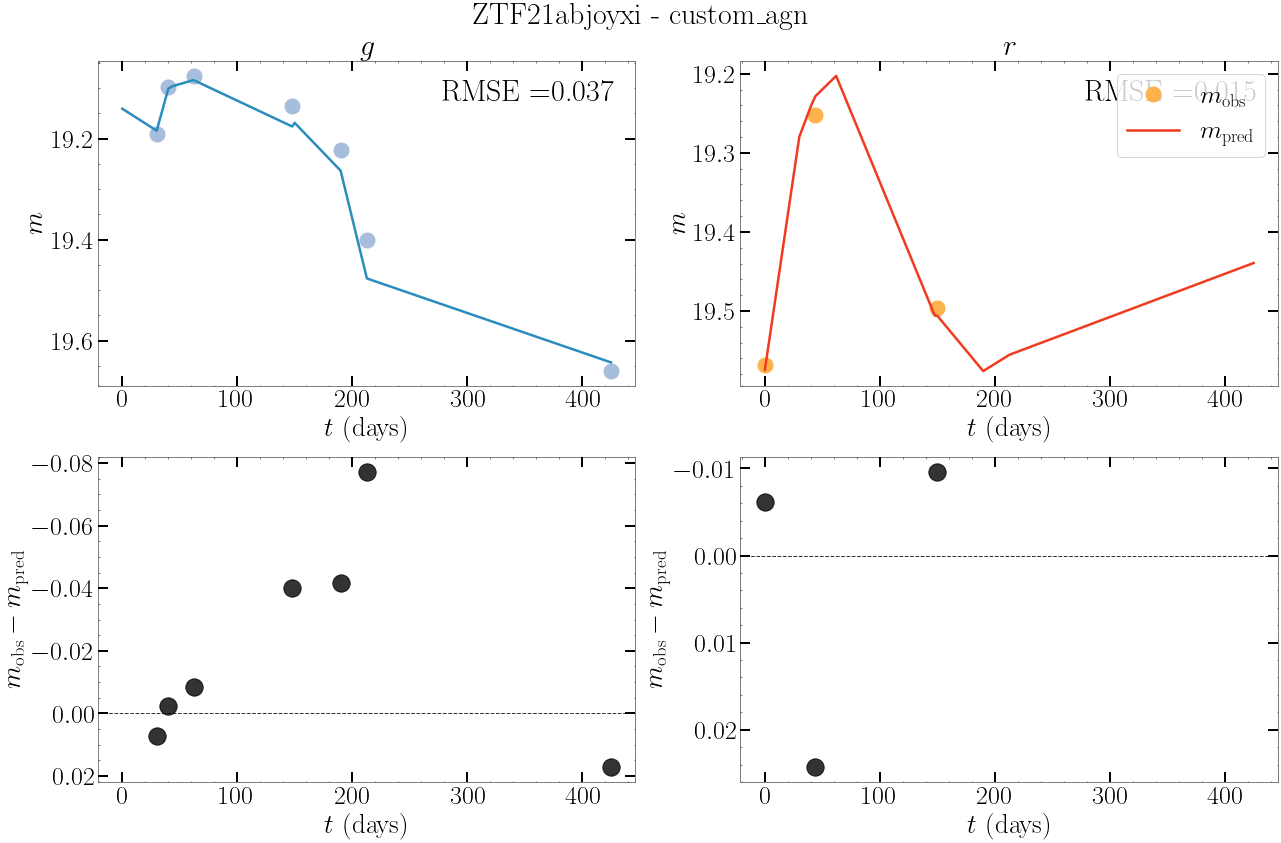

(347, 2) (347, 2) (347, 2) (347, 2)


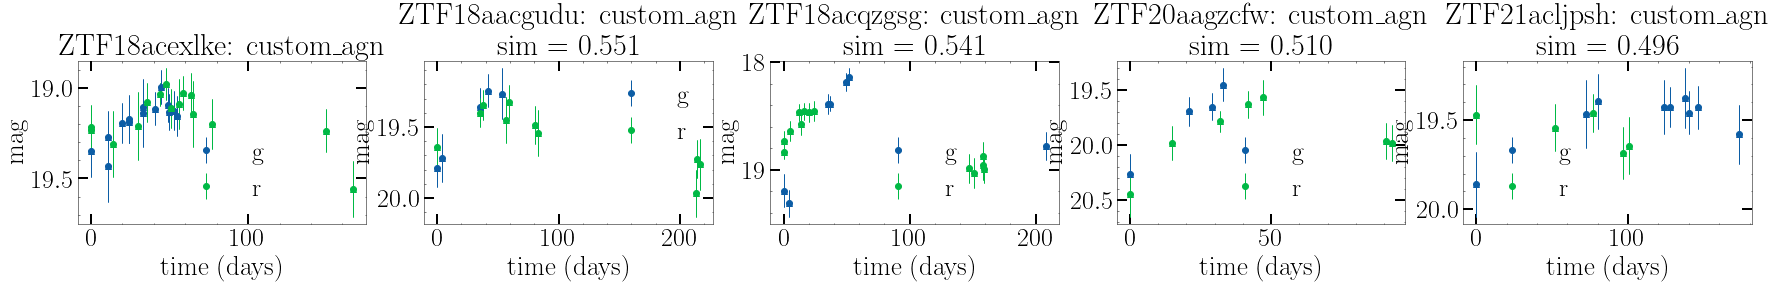

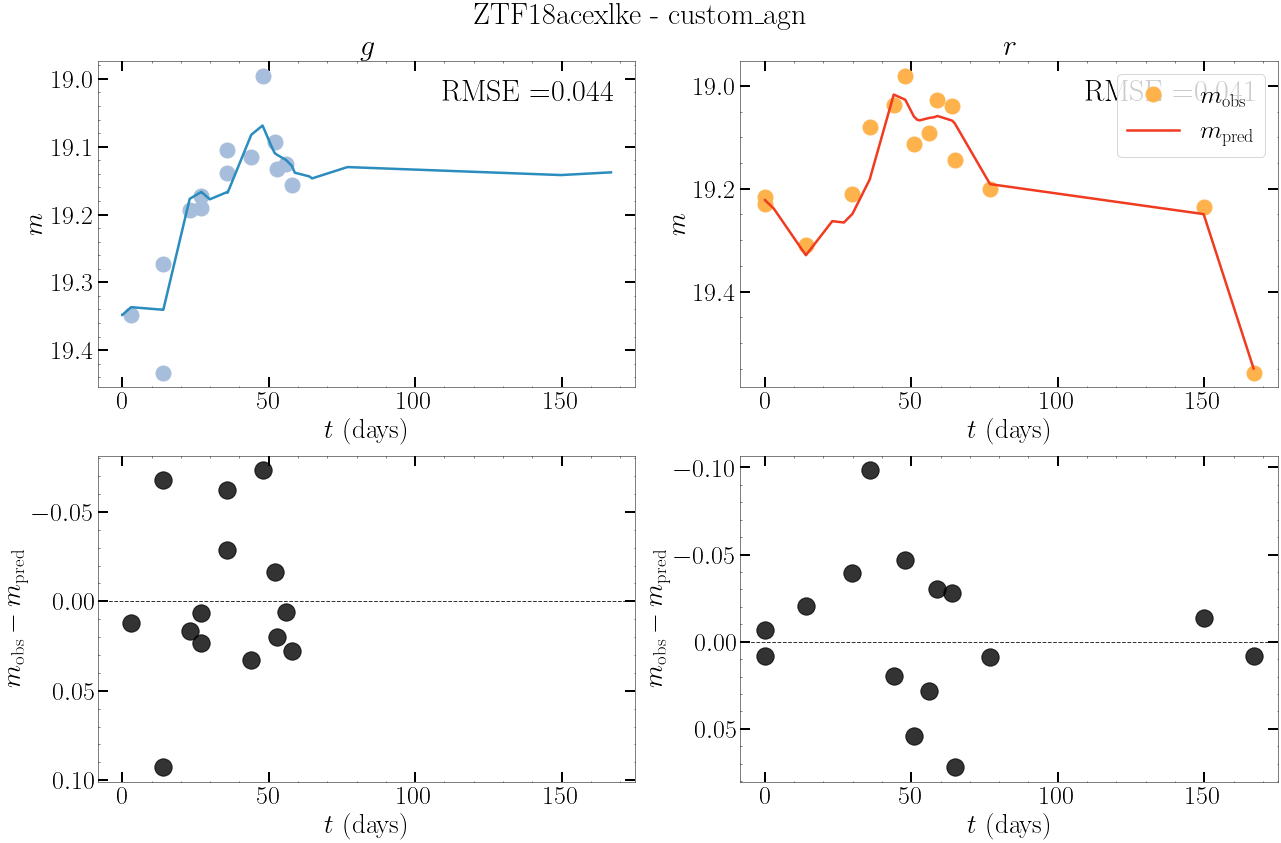

(474, 2) (474, 2) (474, 2) (474, 2)


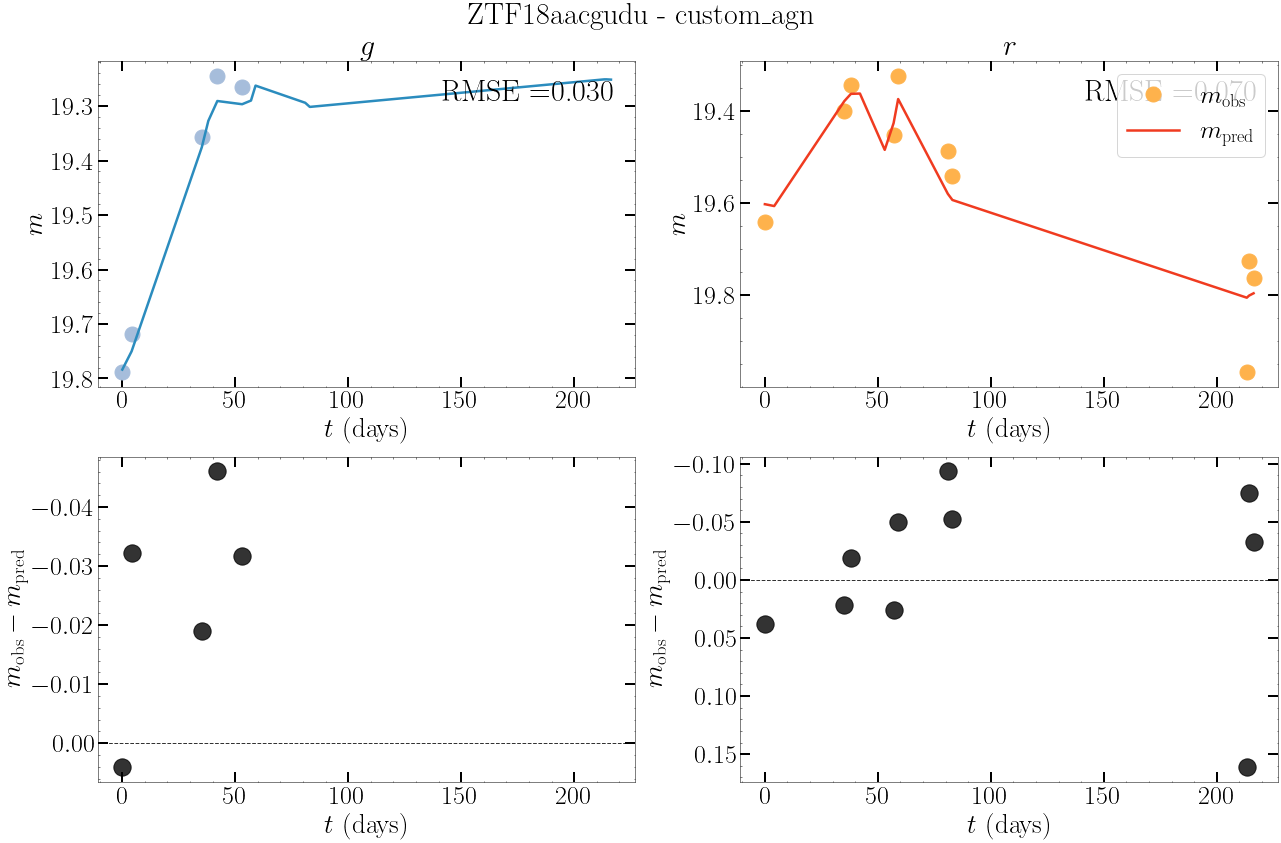

(347, 2) (347, 2) (347, 2) (347, 2)


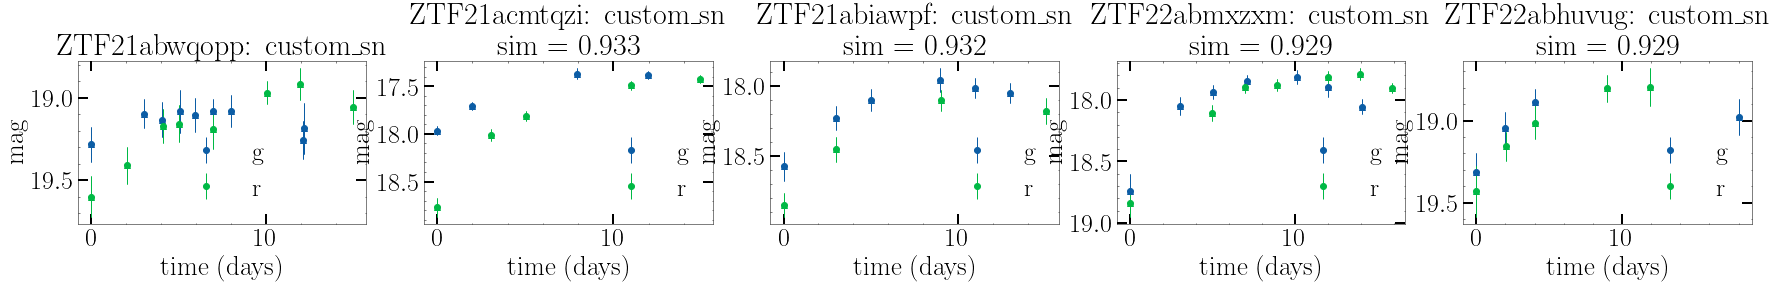

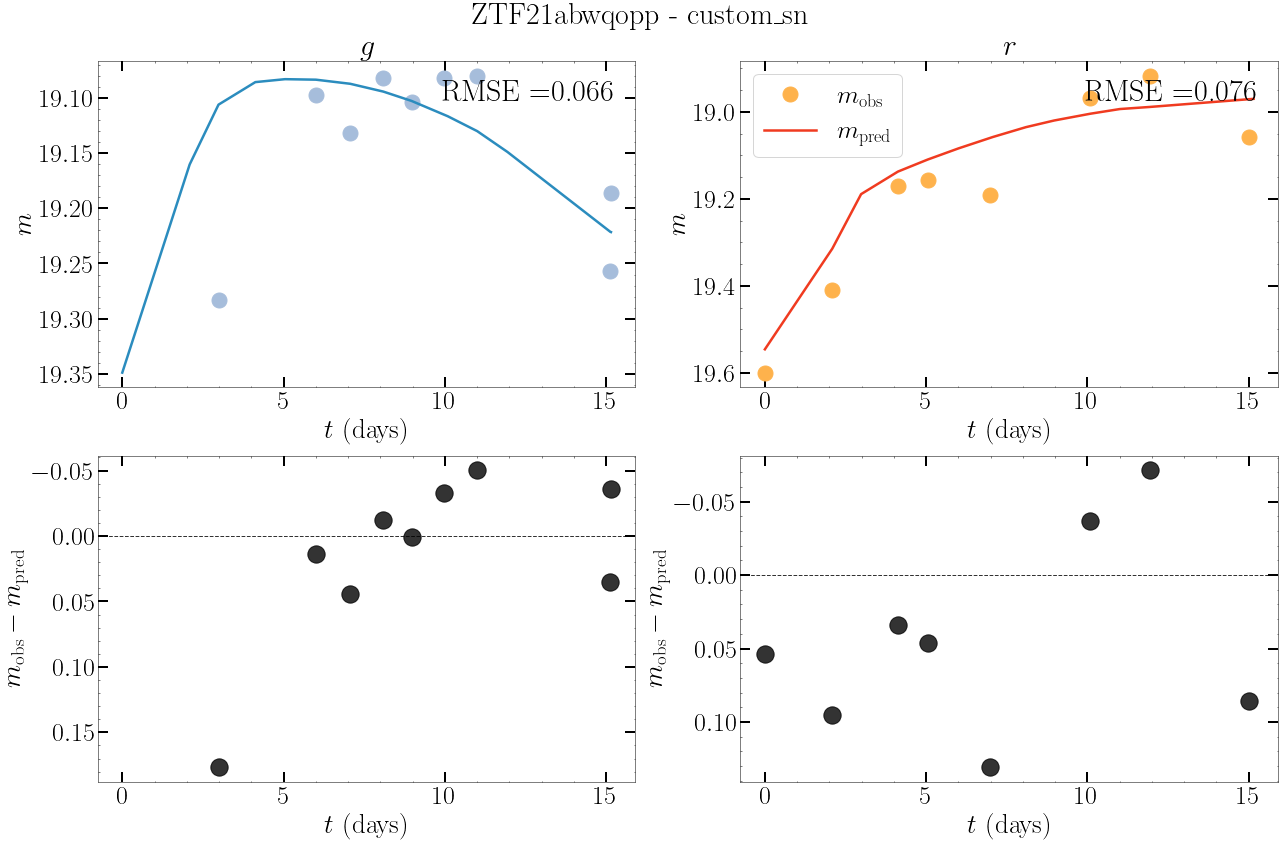

(474, 2) (474, 2) (474, 2) (474, 2)


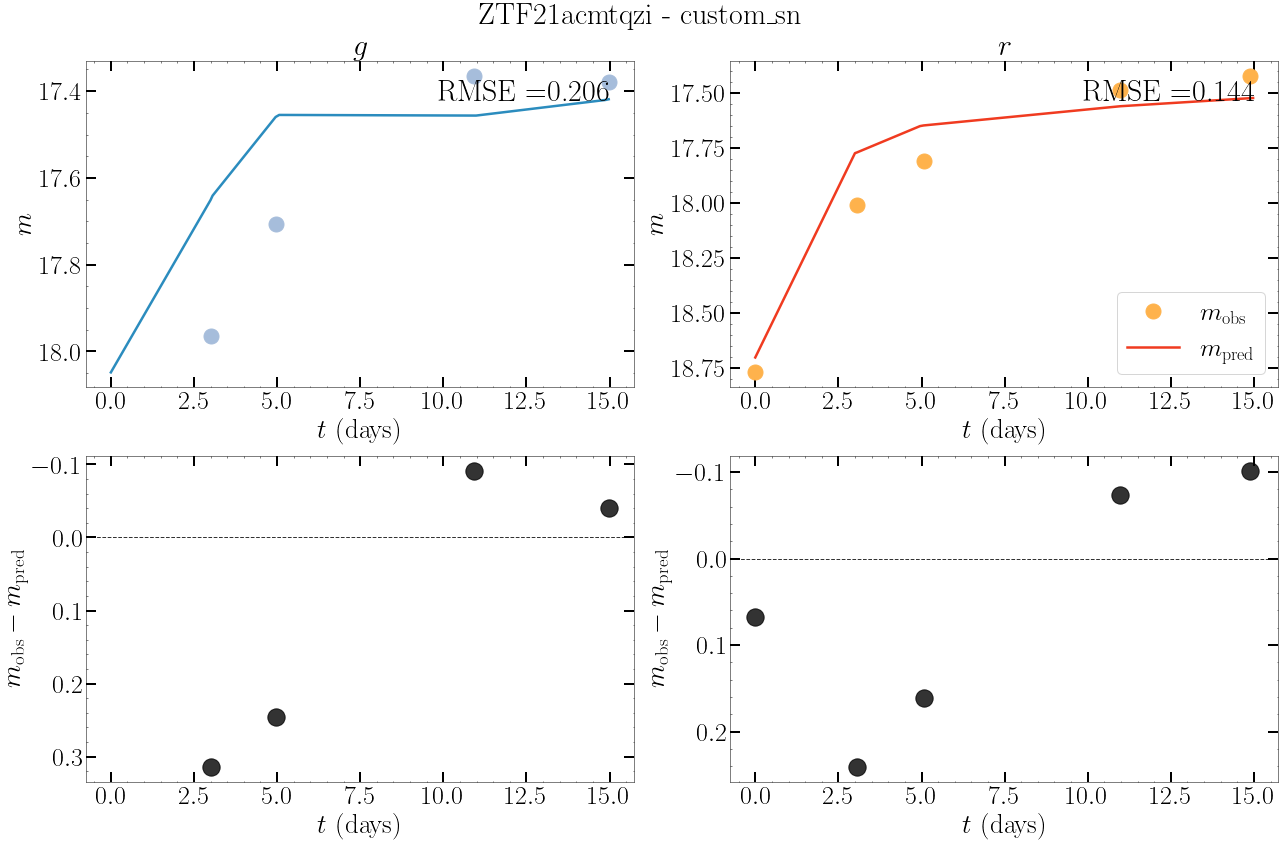

(347, 2) (347, 2) (347, 2) (347, 2)


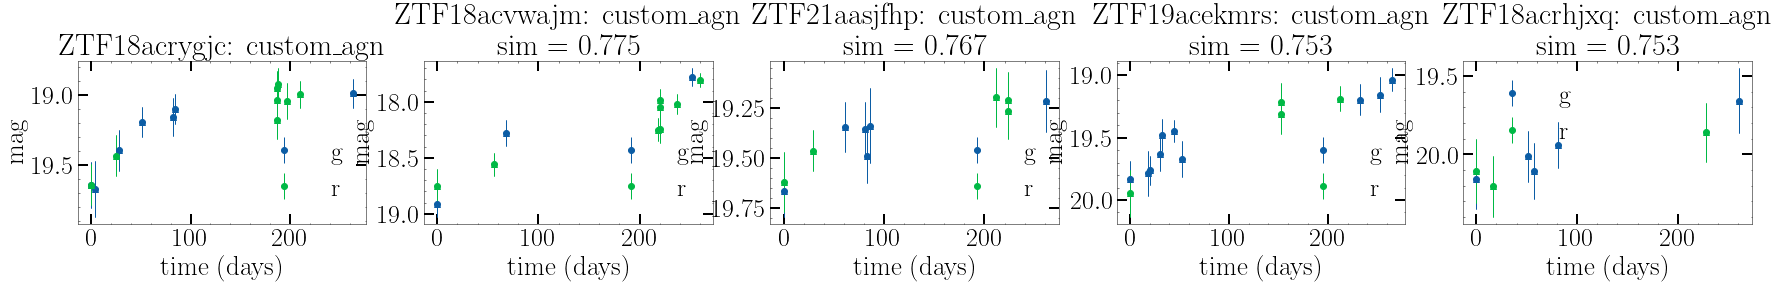

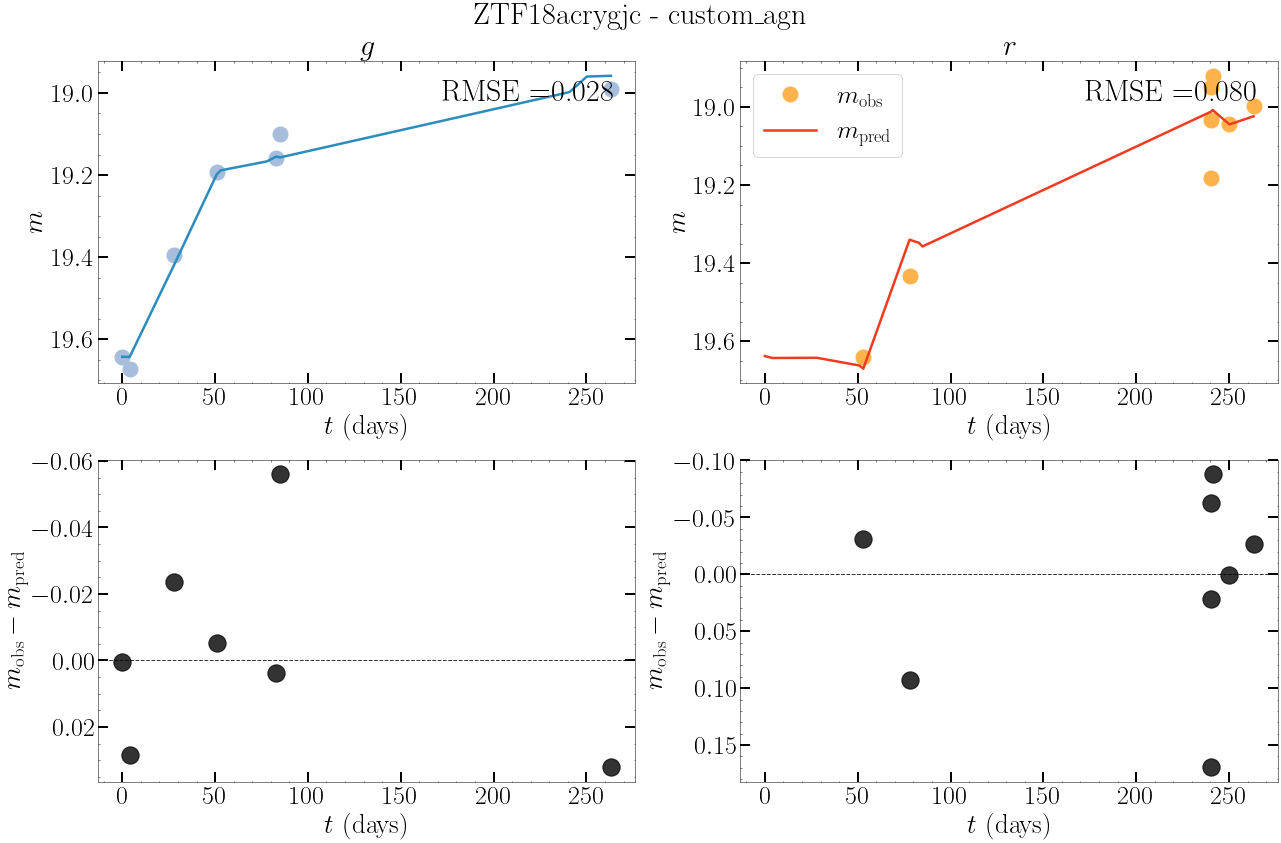

(474, 2) (474, 2) (474, 2) (474, 2)


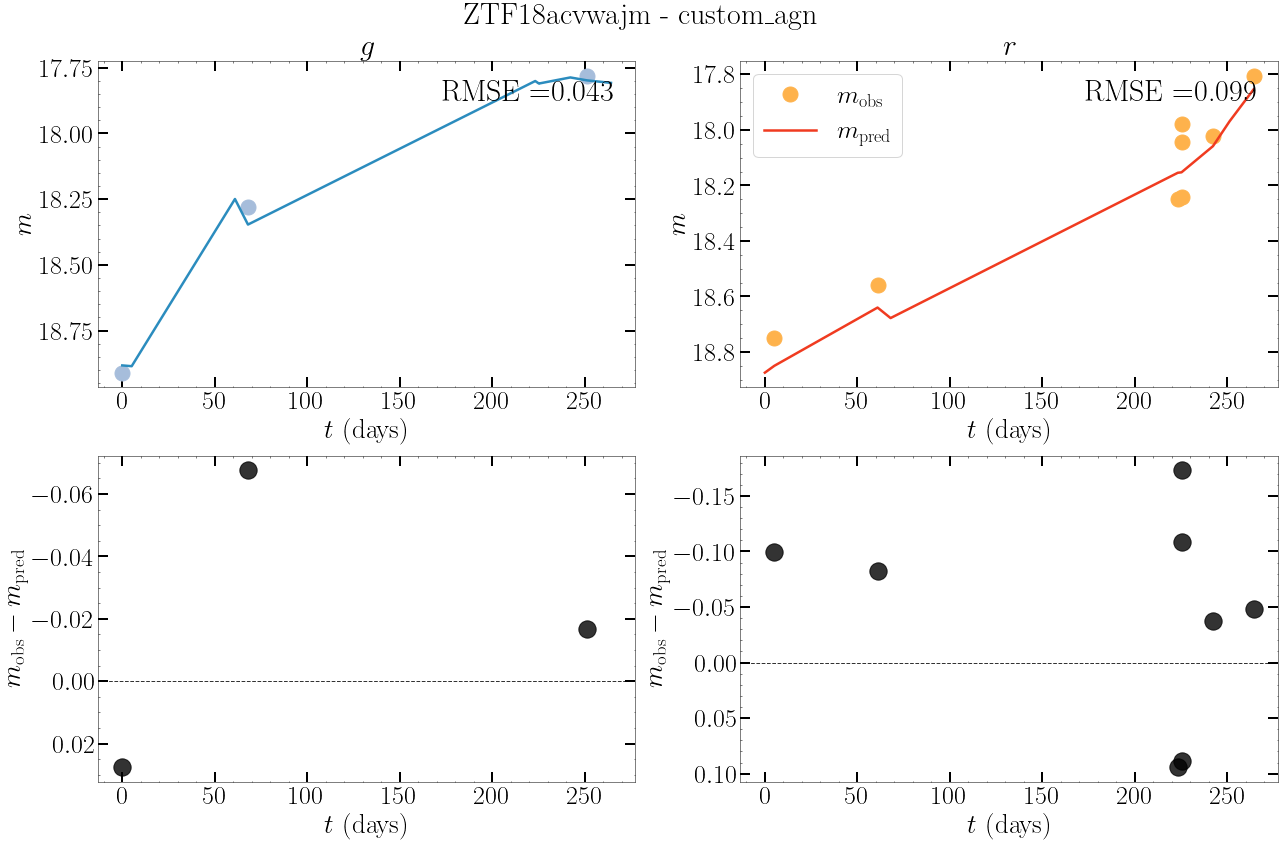

In [38]:
# **NOTE**: THIS ASSUMES TEST EXAMPLES ARE AT THE END.
# THIS IS DECIDED BASED ON THE FOLLOWING DEFINITION IN AN ABOVE CELL:
# `outputs = [train_outputs_condensed, val_outputs_condensed, test_outputs_condensed]`
only_test_outputs = outputs[-num_test_examples:]
assert len(only_test_outputs) == num_test_examples
# loop over test examples since those are queries
for c, idx in enumerate(range(len(only_test_outputs))):
    query_currObjId = test_objIds_dataloader[idx]
    query_currObjId_index = np.where(total_objIds == query_currObjId)
    query_currCommonFinkclass = total_common_finkclasses[query_currObjId_index].squeeze()
    query_currCommonFinkclass = query_currCommonFinkclass[query_currCommonFinkclass != '0']
    assert len(query_currCommonFinkclass) == 1

    fig, ax = plt.subplots(1, k, figsize=(30, 3))
    # Plot query
    assert test_objIds_dataloader[idx] == objIds_dataloader[-num_test_examples + idx]
    plot_lc_ax_visualize(
        df_alerts_pandas, test_objIds_dataloader[idx],
        ax=ax[0], title_suffix=query_currCommonFinkclass[0]
    )

    # Extract the similarity search result for the current test example
    row = results.iloc[-num_test_examples + idx]
    # Ignore the first entry since it will be same as query with sim=1.0
    in_test_or_not = []
    in_val_or_not = []
    currCommonFinkclasses = []
    for i_ in range(1, k):
        currObjId = objIds_dataloader[int(row[f'sim_id_{i_}'])]
        if currObjId in train_objIds_dataloader:
            in_test_or_not.append(0)
            in_val_or_not.append(0)
        elif currObjId in val_objIds_dataloader:
            in_test_or_not.append(0)
            in_val_or_not.append(1)
        elif currObjId in test_objIds_dataloader:
            in_test_or_not.append(1)
            in_val_or_not.append(0)

        currObjId_index = np.where(total_objIds == currObjId)
        # NOTE: The calculation of `currCommonFinkclass` has one caveat
        # which is that if there are multiple modes (two classes equally common)
        # then we would inadvertently only select the first mode.
        # But this is not very common and probably is okay.
        currCommonFinkclass = total_common_finkclasses[currObjId_index].squeeze()
        currCommonFinkclass = currCommonFinkclass[currCommonFinkclass != '0']

        assert len(currCommonFinkclass) == 1
        currCommonFinkclasses.append(currCommonFinkclass[0])
        assert df_alerts_pandas[df_alerts_pandas['objectId'] == currObjId]['finkclass'].mode().tolist()[0] == currCommonFinkclass[0] 

        plot_lc_ax_visualize(
            df_alerts_pandas, objIds_dataloader[int(row[f'sim_id_{i_}'])], ax=ax[i_],
            title_suffix=currCommonFinkclass[0]+f'\nsim = {row[f"sim_{i_}"]:.3f}'
        )  # this is the closest to the query in the database.

    if show_decoded_lcs_along_with_sim_search:
        # Also, we pass the same min_max_mags even if we use local normalization
        # for the mags because in plot_decoded_lc, we select the min/max for
        # that light curve, so it takes care of that.

        # Plot query decoded lc
        _ = plot_decoded_lc(
            decoded_lcs_test, key=dlte[idx], objId=query_currObjId,
            unnormalize_lcs=True, min_time=min_time, max_time=max_time,
            min_max_mags=min_max_mags, prob_plot=False, also_show_sigmapsf=False,
            whichclass=query_currCommonFinkclass[0]
        )
        plt.show()

        # Only show decoded lc for the closest (note, we ignore
        # sim_id_0 because it will be the same as query)
        # `in_test_or_not[0]` gives whether the closest example
        # (excluding 0th element) is in test set or not
        # It's `in_test_or_not[0]` and not `in_test_or_not[1]`
        # to get the closest element to the query because
        # `in_test_or_not` is populated from index 1:
        # see `for i_ in range(1, k)`. Same for `in_val_or_not`.
        if in_test_or_not[0]:
            use_decoded_lcs = decoded_lcs_test
        elif in_val_or_not[0]:
            use_decoded_lcs = decoded_lcs_val
        else:
            use_decoded_lcs = decoded_lcs_train

        _ = plot_decoded_lc(
            use_decoded_lcs, key=dltr_v_te[int(row['sim_id_1'])],
            objId=objIds_dataloader[int(row[f'sim_id_1'])], unnormalize_lcs=True,
            min_time=min_time, max_time=max_time, min_max_mags=min_max_mags,
            prob_plot=False, also_show_sigmapsf=False, whichclass=currCommonFinkclasses[0]
        )
        plt.show()
        plt.close()

    if c == 3:
        break

# Diagnostic plot

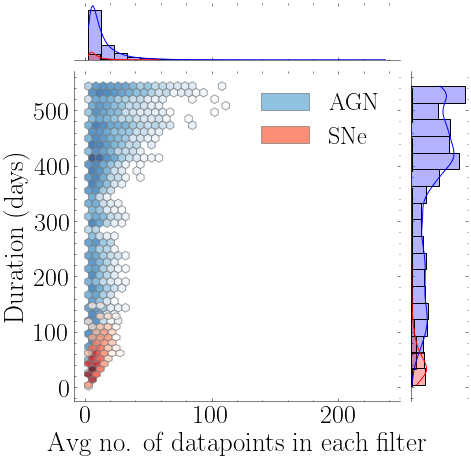

In [39]:
import seaborn as sns
from matplotlib.patches import Patch

num_datapoints_lcs = np.load('num_datapoints_lcs.npy')
classes = np.array([0 if tcf == 'custom_sn' else 1 for tcf in total_common_finkclasses])
duration_lcs = np.load('duration_lcs.npy')

g = sns.JointGrid()

x1 = num_datapoints_lcs[classes==1]/2
y1 = (duration_lcs/24)[classes==1]
x2 = num_datapoints_lcs[classes==0]/2
y2 = (duration_lcs/24)[classes==0]

g.ax_joint.hexbin(
    x1, y1, mincnt=3, bins='log', edgecolor='grey',
    gridsize=40, cmap="Blues", alpha=0.75, label='AGN'
)

g.ax_joint.hexbin(
    x2, y2, mincnt=3, bins='log', edgecolor='grey',
    gridsize=(9, 28), cmap="Reds", alpha=0.75, label='SNe'
)

# Add marginal histograms
sns.histplot(x=x1, ax=g.ax_marg_x, color="blue", kde=True, alpha=0.3, binwidth=10)#, log_scale=True)
sns.histplot(x=x2, ax=g.ax_marg_x, color="red", kde=True, alpha=0.3, binwidth=10)#, log_scale=True)

sns.histplot(y=y1, ax=g.ax_marg_y, color="blue", kde=True, alpha=0.3, binwidth=30)#, log_scale=True)
sns.histplot(y=y2, ax=g.ax_marg_y, color="red", kde=True, alpha=0.3, binwidth=30)#, log_scale=True)

g.ax_joint.set_xlabel('Avg no. of datapoints in each filter', fontsize=axeslabelsize)
g.ax_joint.set_ylabel('Duration (days)', fontsize=axeslabelsize)

g.ax_joint.tick_params(axis='x', labelsize=ticklabelsize)
g.ax_joint.tick_params(axis='y', labelsize=ticklabelsize)

cmap1 = plt.cm.Blues
cmap2 = plt.cm.Reds
blue_mid = cmap1(0.5)
red_mid  = cmap2(0.5)

proxy1 = Patch(facecolor=blue_mid, edgecolor='grey', alpha=0.75, label='AGN')
proxy2 = Patch(facecolor=red_mid,  edgecolor='grey', alpha=0.75, label='SNe')

g.ax_joint.legend(
    handles=[proxy1, proxy2], loc='best', fontsize=ticklabelsize-2
)

# g.ax_joint.set_xlim([0, 150])

plt.show()

# Interpolation

Instead of aiming for an interpolation that perfectly matches the observed points, our aim is to capture more general evolution (but still capturing local structure).

In [40]:
decoded_lcs_test = np.load('evaluate_test_decoded_lcs.npz')
dlte = list(decoded_lcs_test.keys())
decoded_lcs_test.f.arr_2.shape

(4, 347, 2)

In [41]:
duration_lcs = np.load('duration_lcs.npy')

Total 3131 examples with mode = "random"
(347, 2) (347, 2) (347, 2) (347, 2)


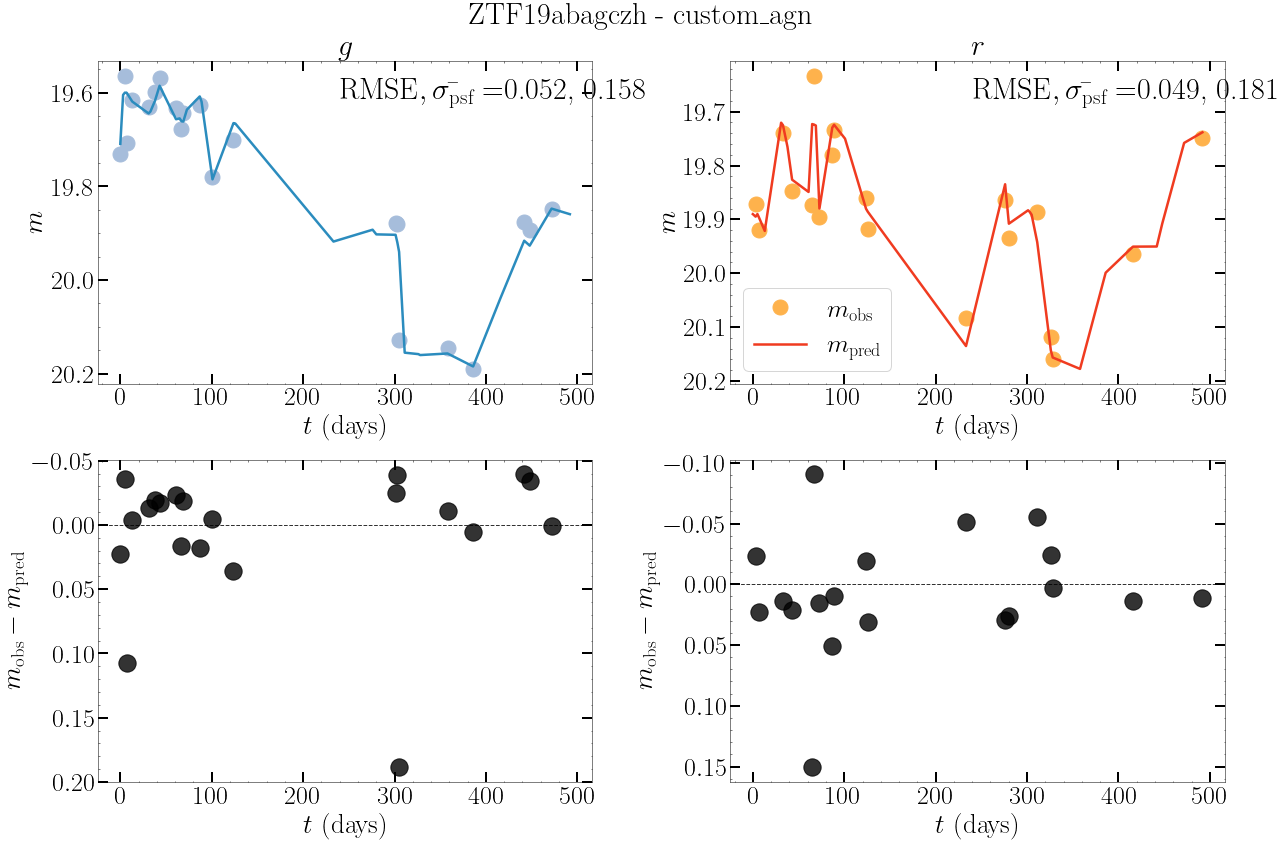

(347, 2) (347, 2) (347, 2) (347, 2)


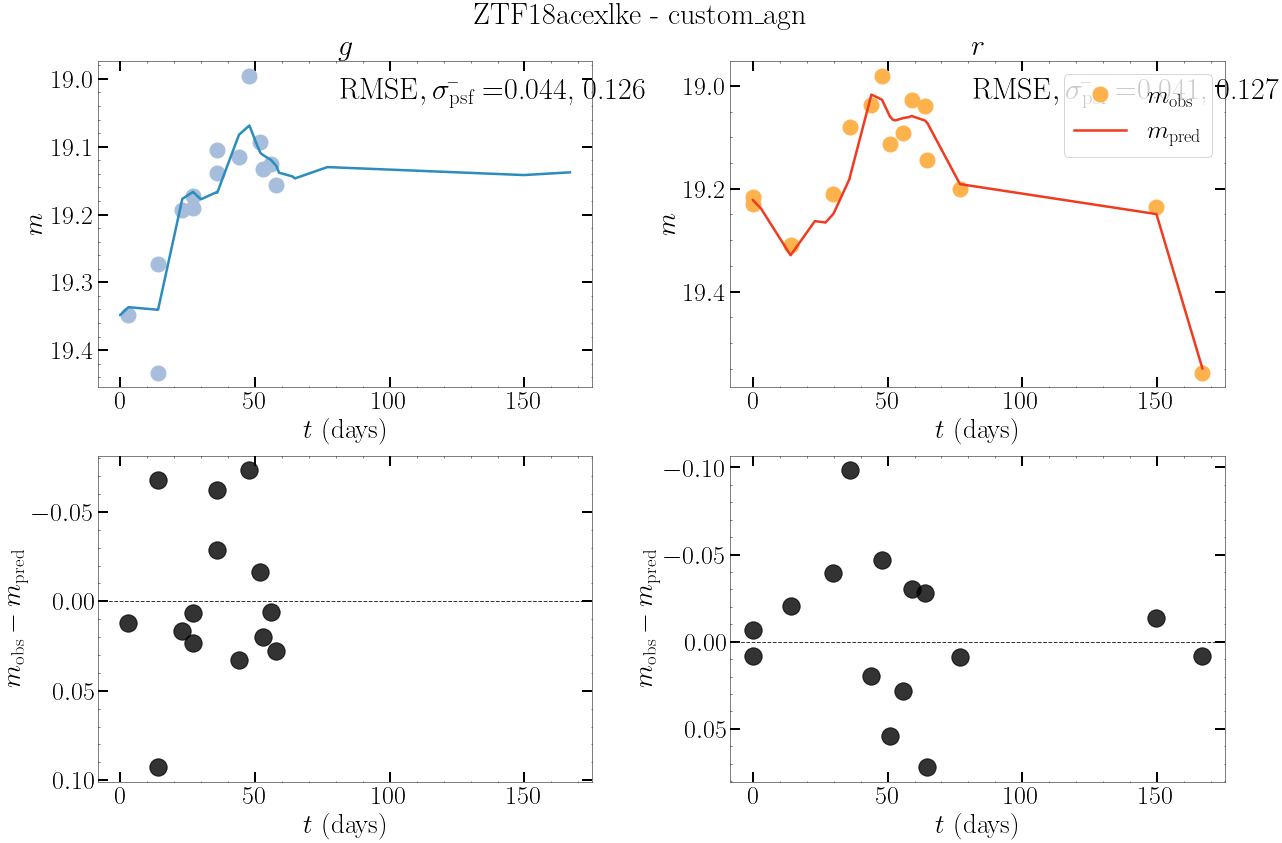

(347, 2) (347, 2) (347, 2) (347, 2)


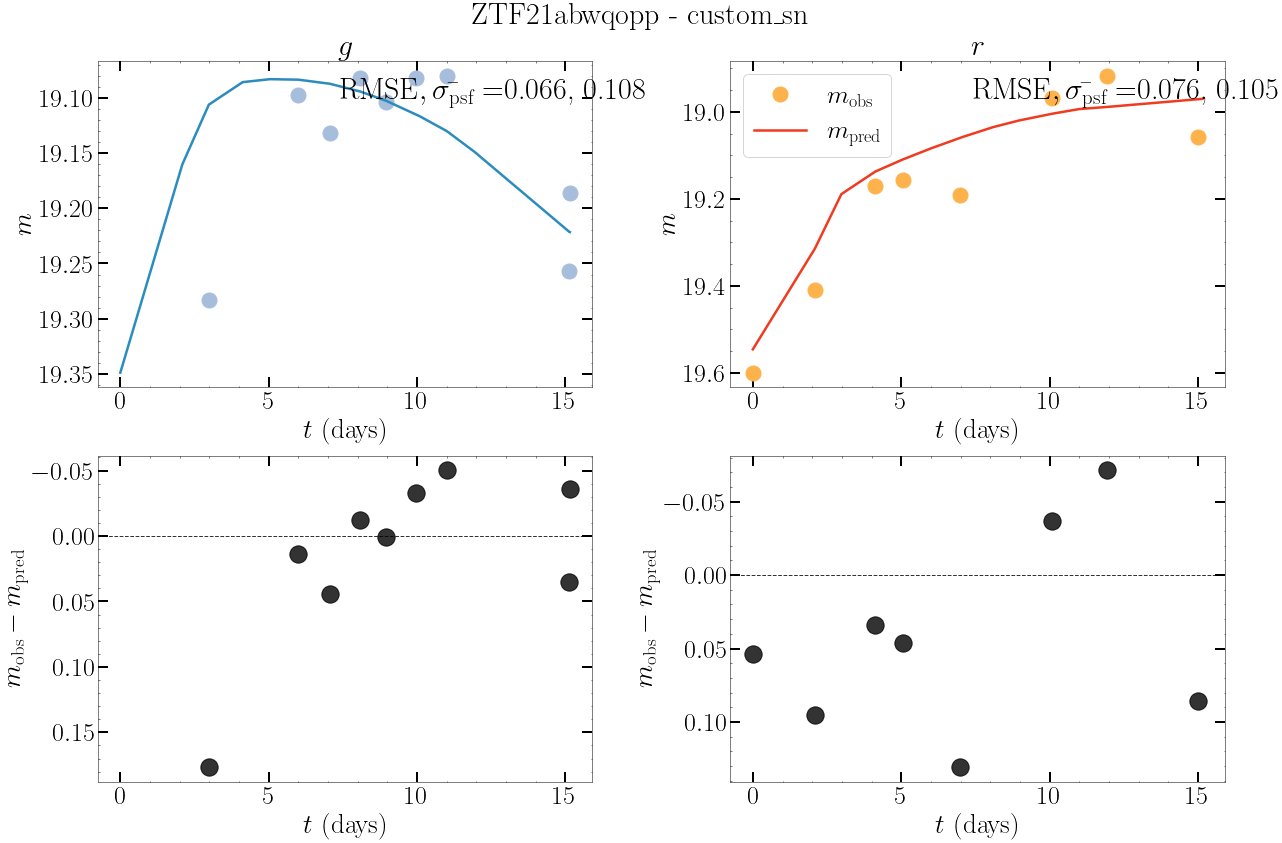

Total 318 examples with mode = "low_N_high_D"
(347, 2) (347, 2) (347, 2) (347, 2)


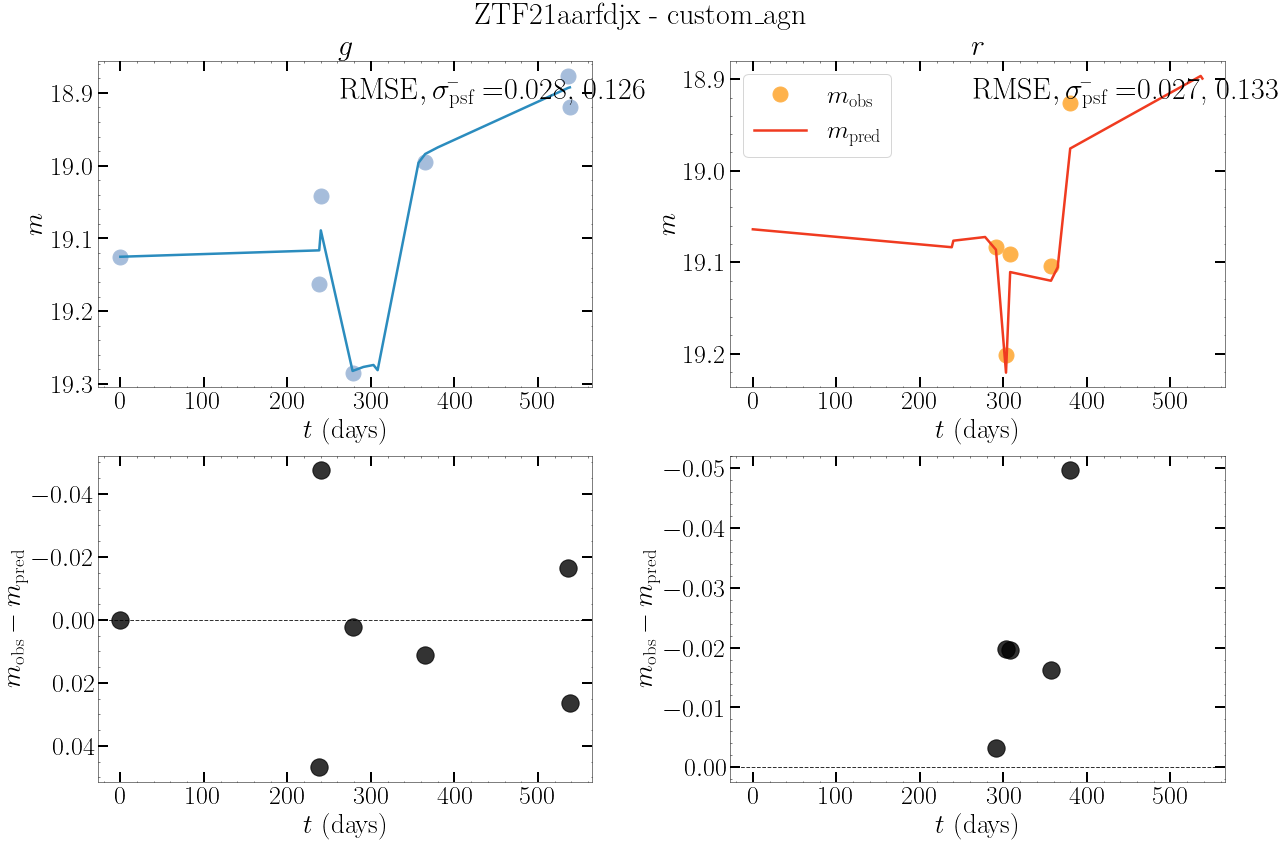

(347, 2) (347, 2) (347, 2) (347, 2)


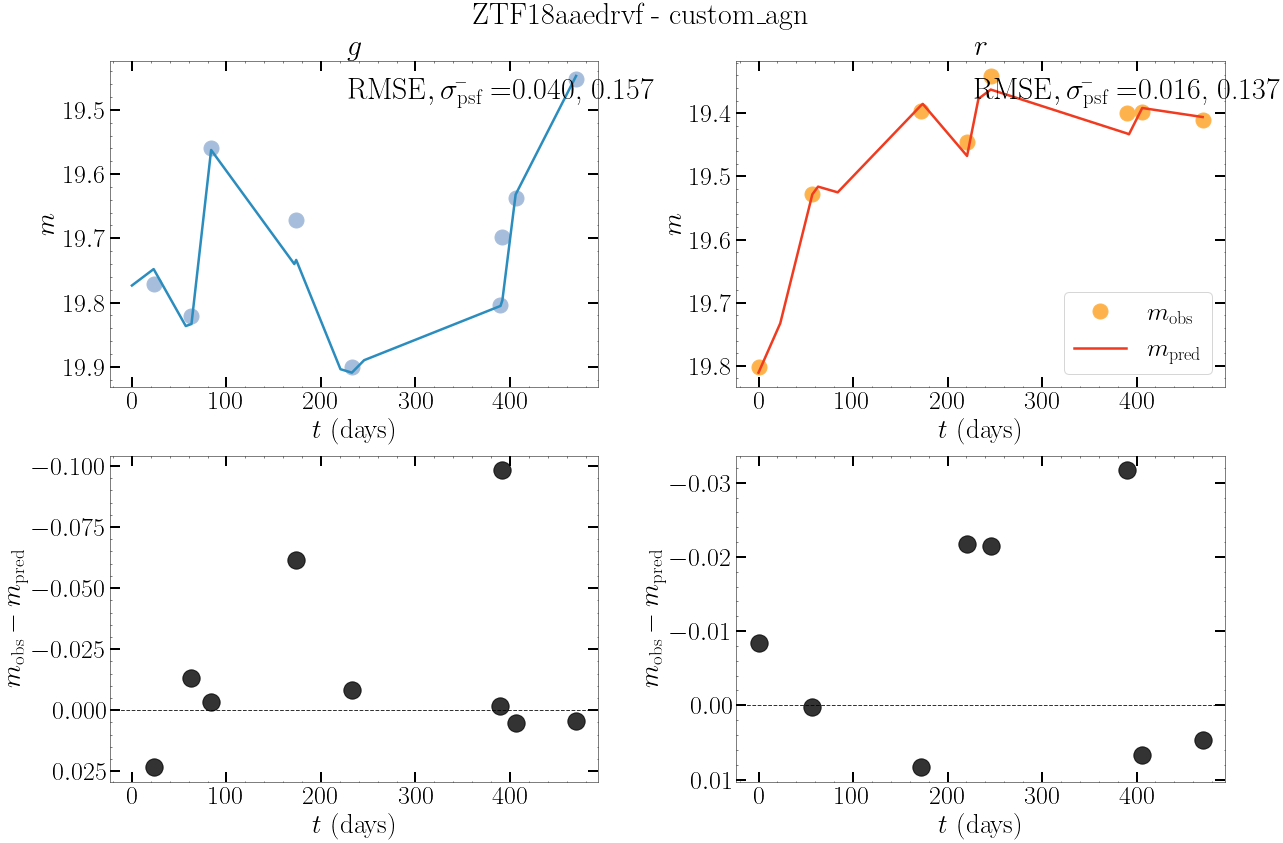

(347, 2) (347, 2) (347, 2) (347, 2)


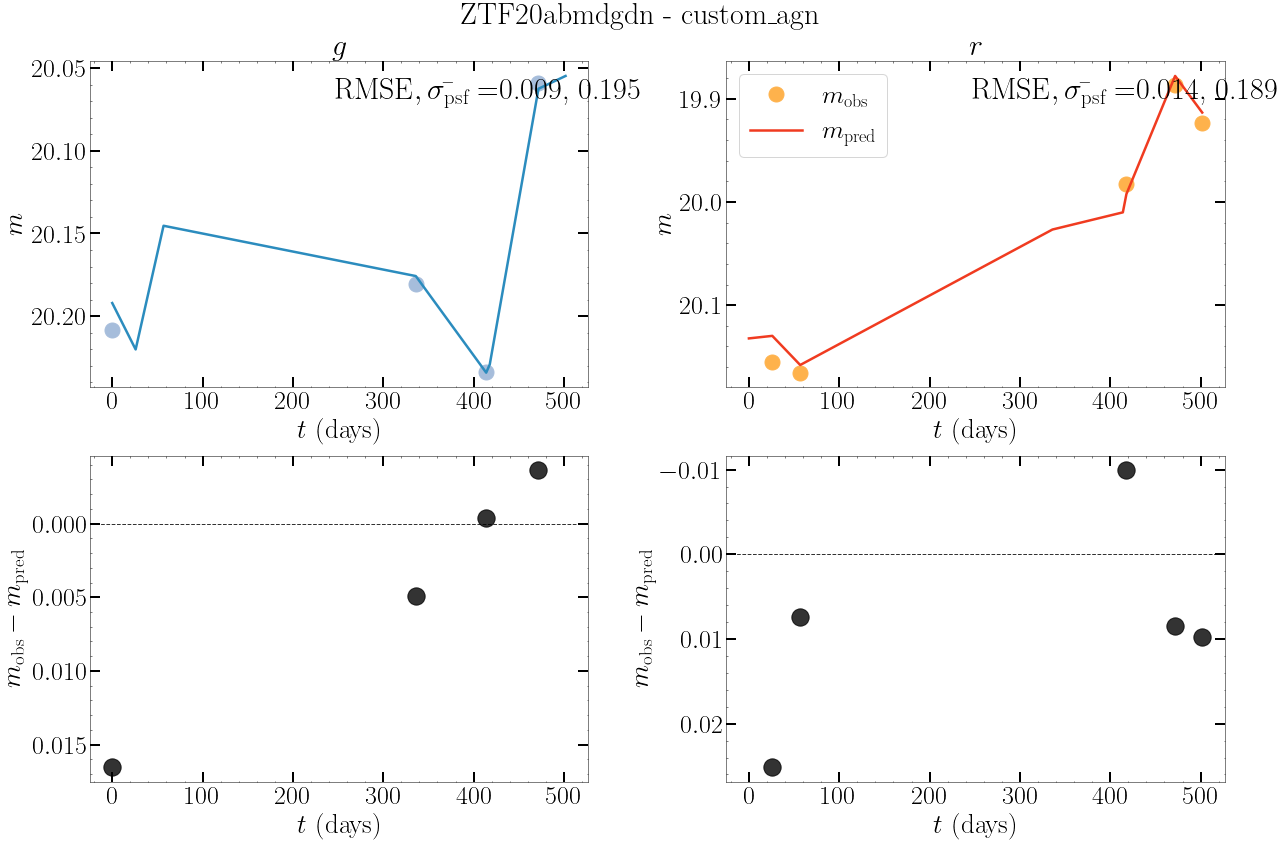

Total 877 examples with mode = "low_N_low_D"
(347, 2) (347, 2) (347, 2) (347, 2)


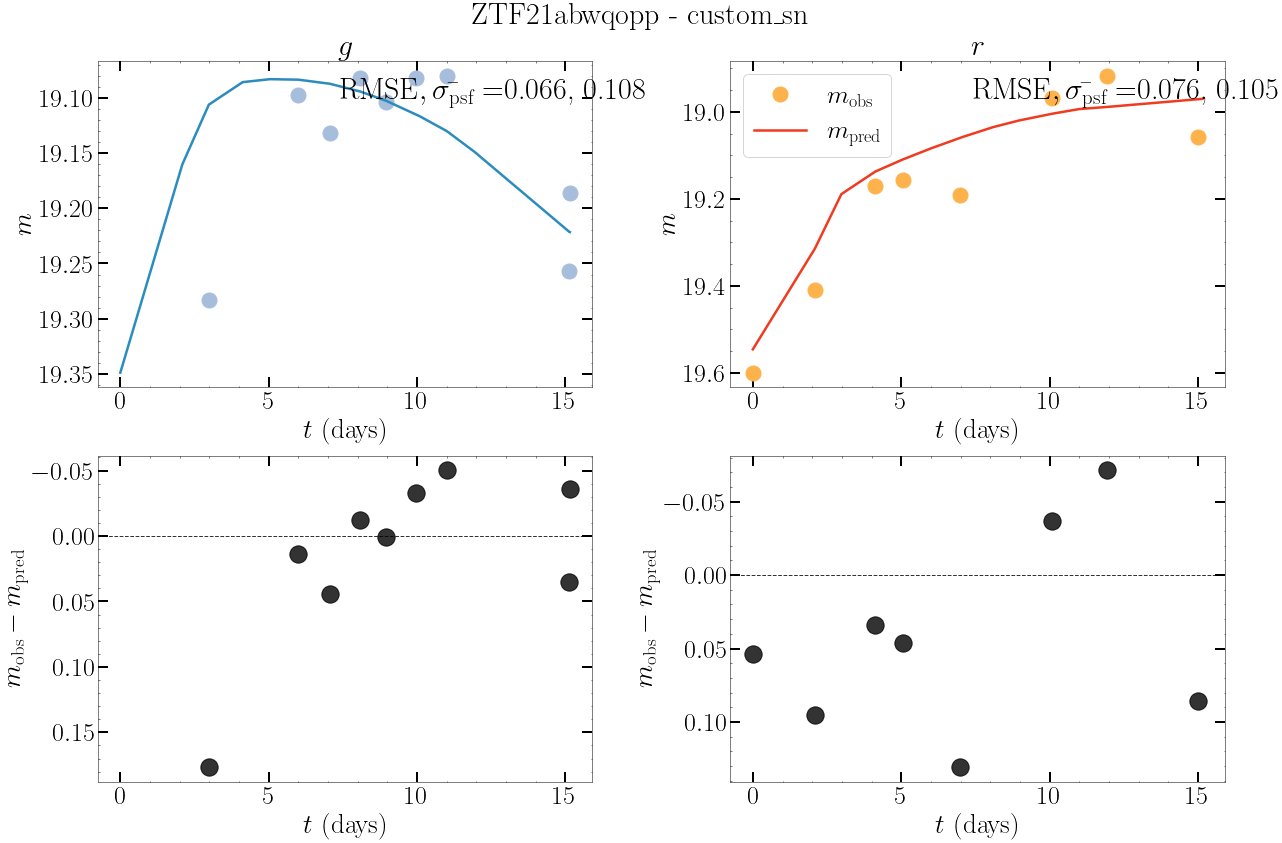

(347, 2) (347, 2) (347, 2) (347, 2)


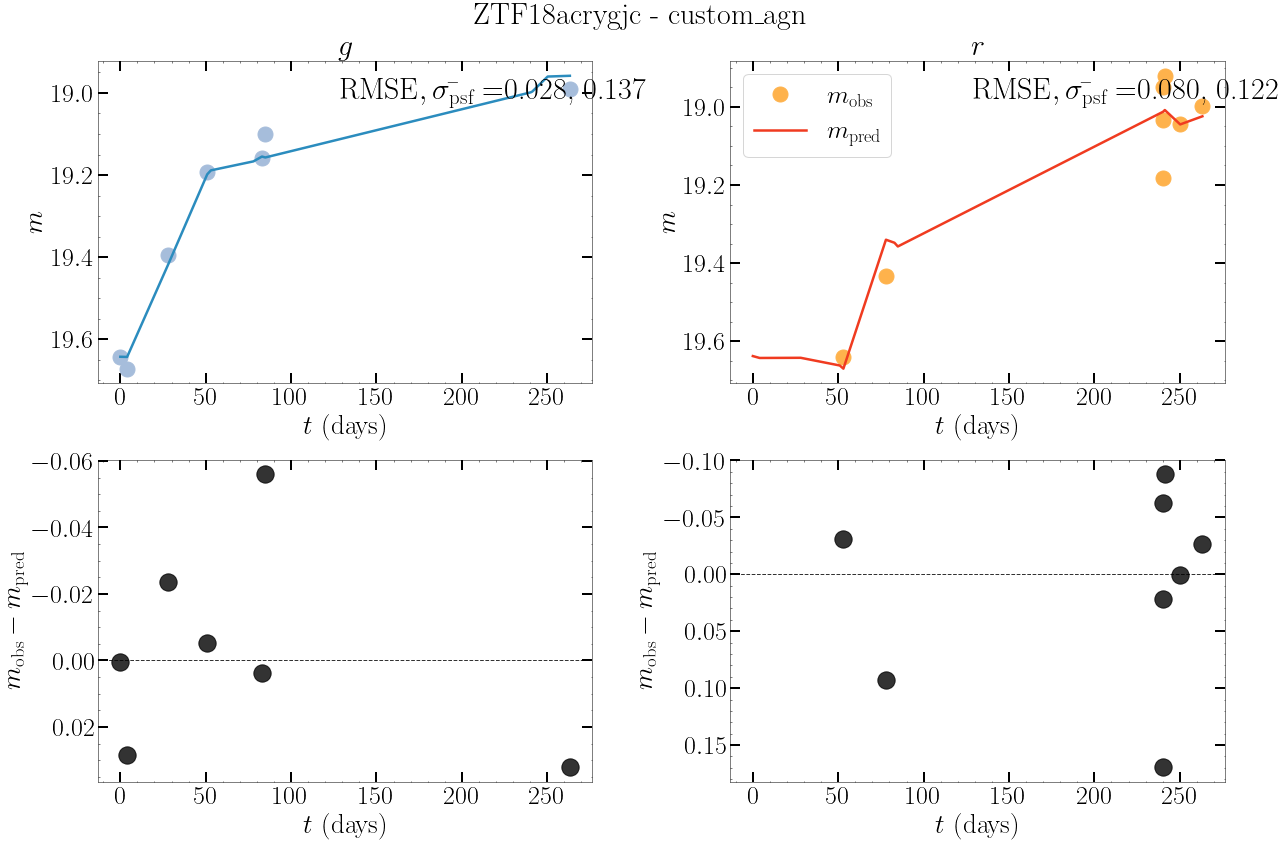

(347, 2) (347, 2) (347, 2) (347, 2)


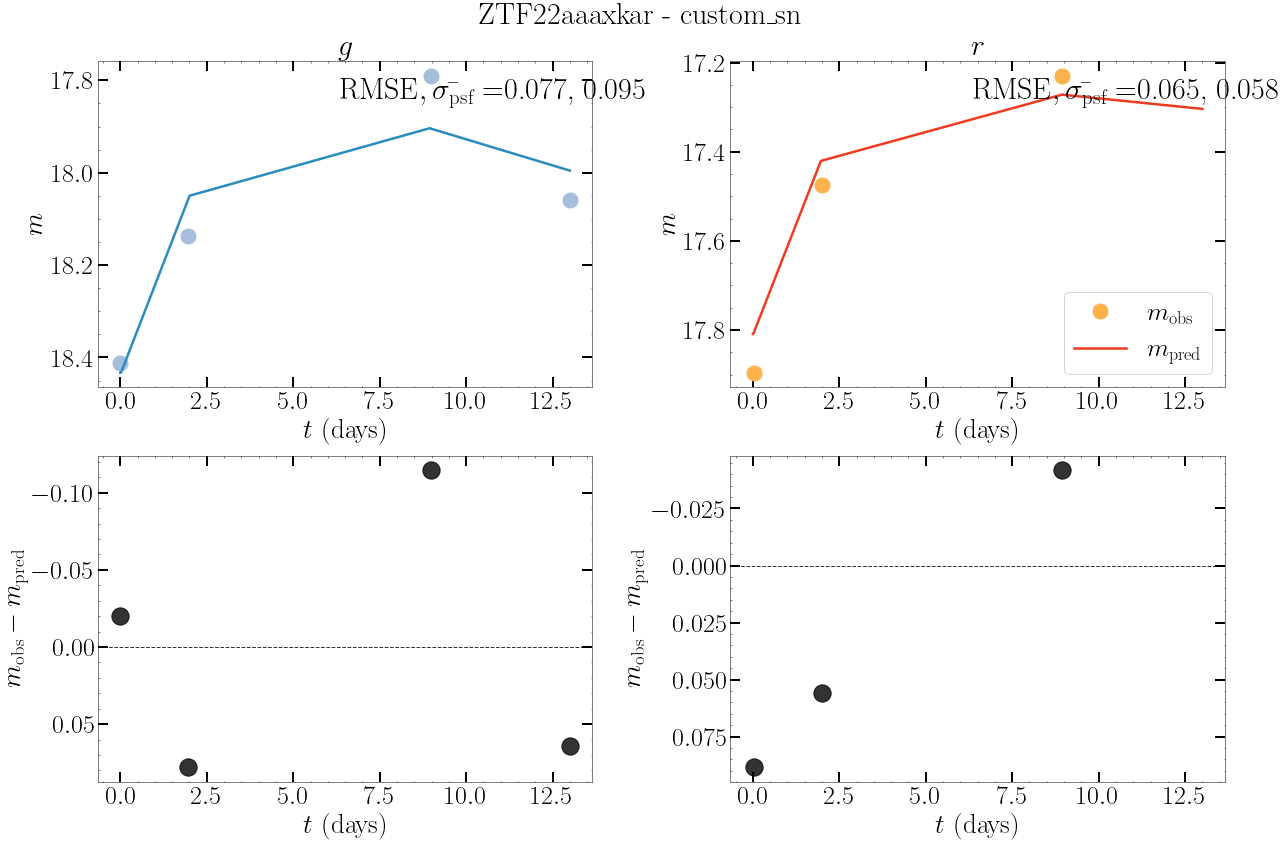

Total 820 examples with mode = "high_N_high_D"
(347, 2) (347, 2) (347, 2) (347, 2)


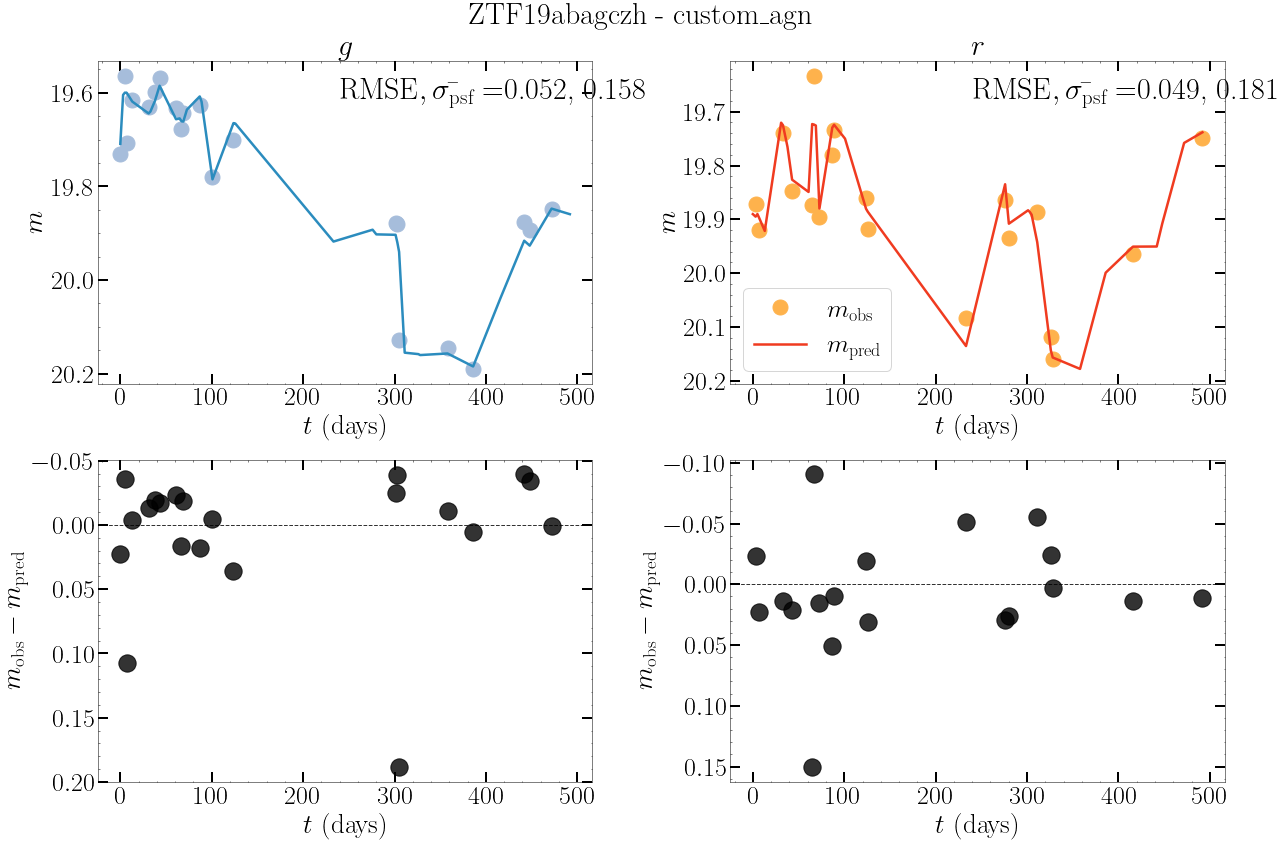

(347, 2) (347, 2) (347, 2) (347, 2)


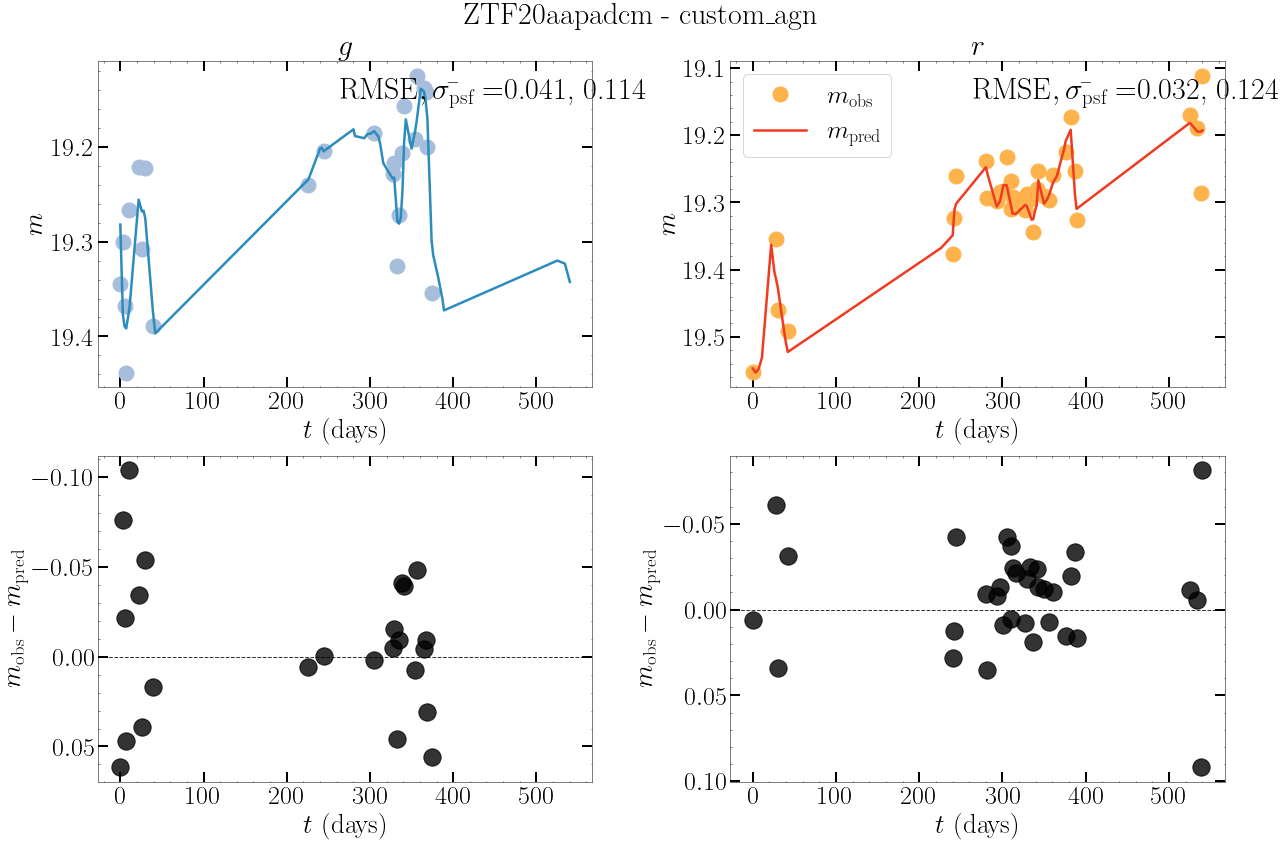

(347, 2) (347, 2) (347, 2) (347, 2)


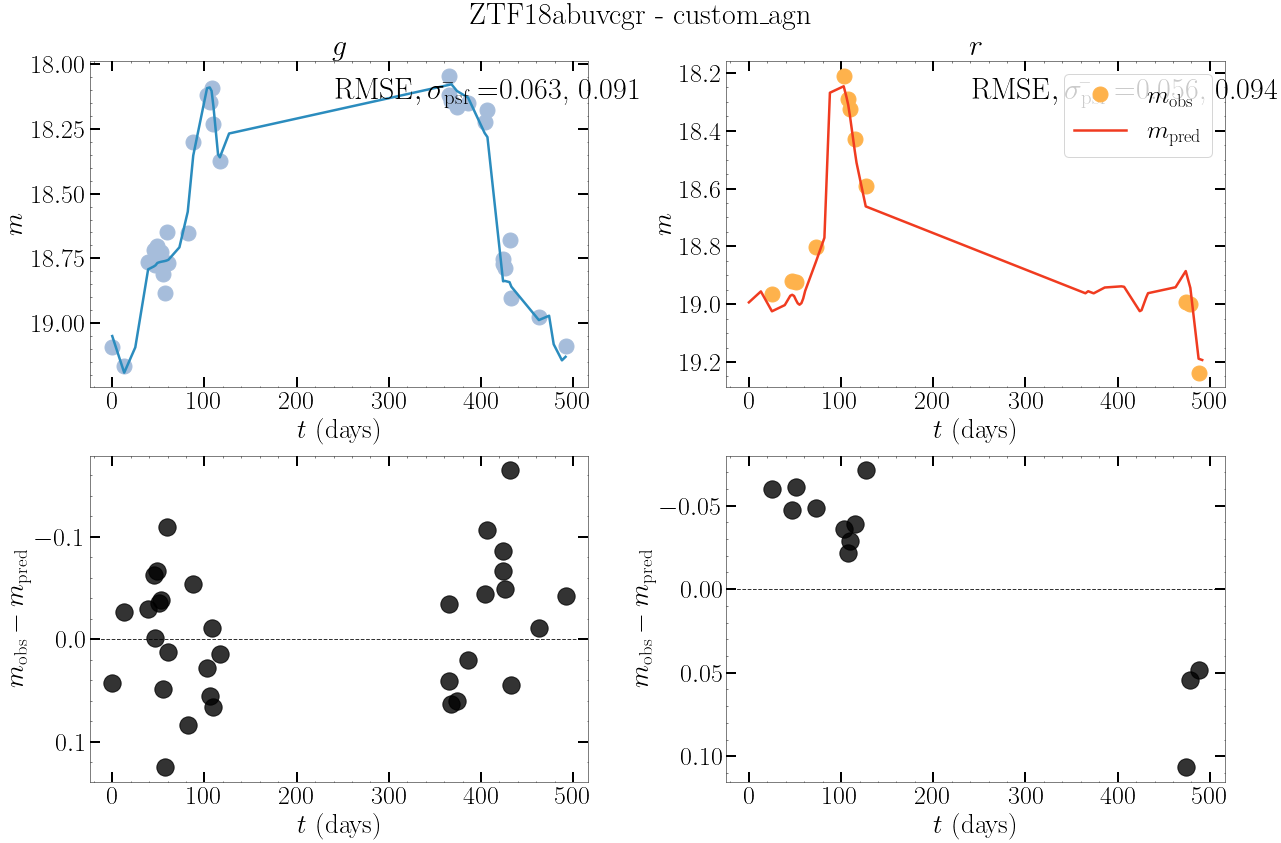

Total 282 examples with mode = "high_N_low_D"
(347, 2) (347, 2) (347, 2) (347, 2)


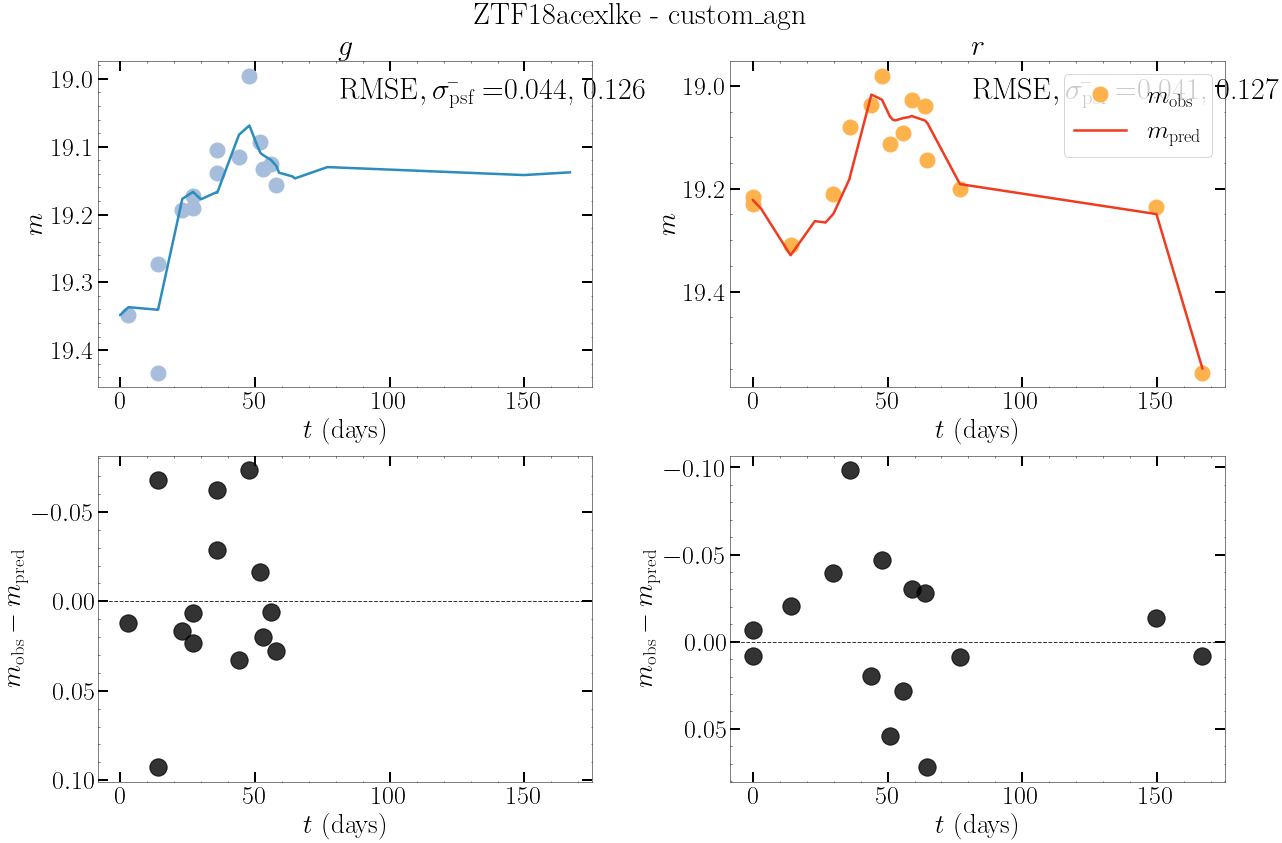

(347, 2) (347, 2) (347, 2) (347, 2)


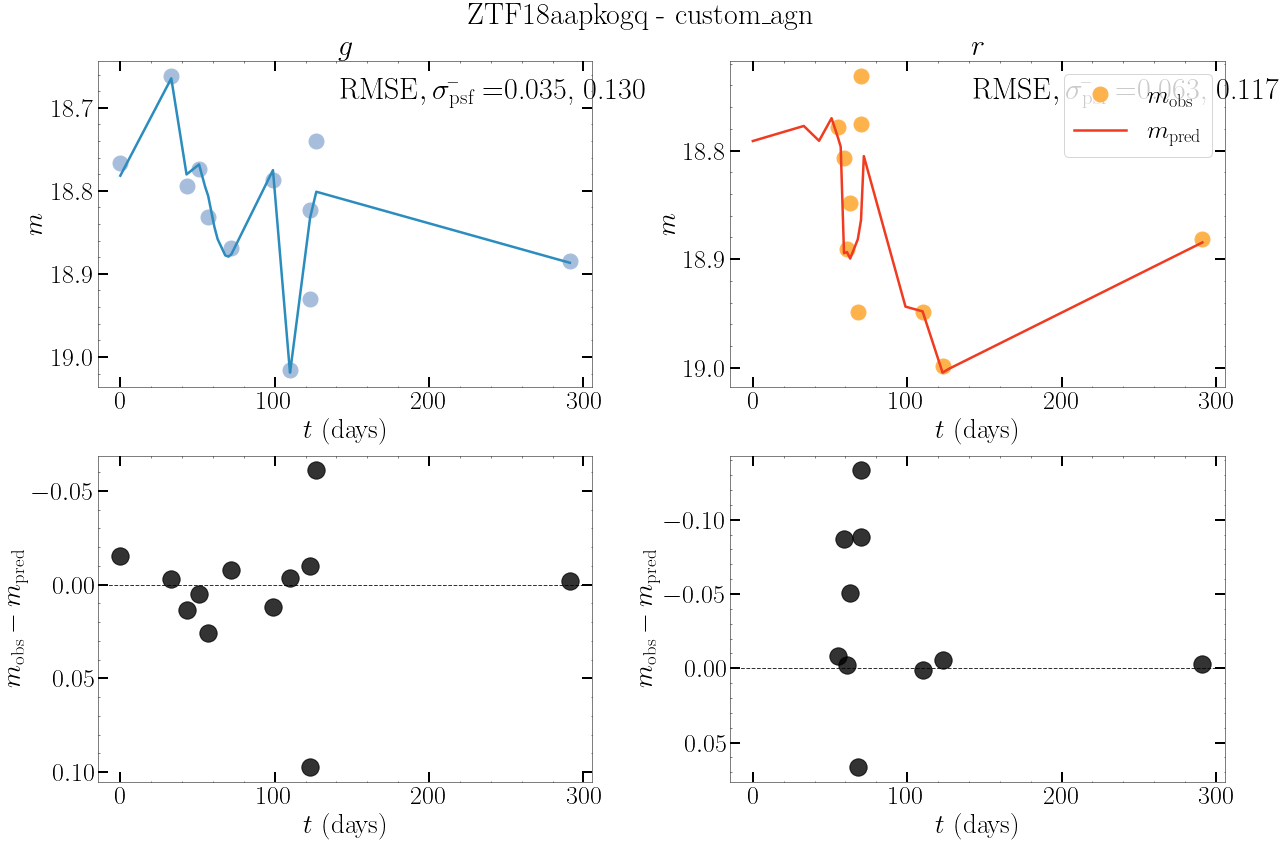

(347, 2) (347, 2) (347, 2) (347, 2)


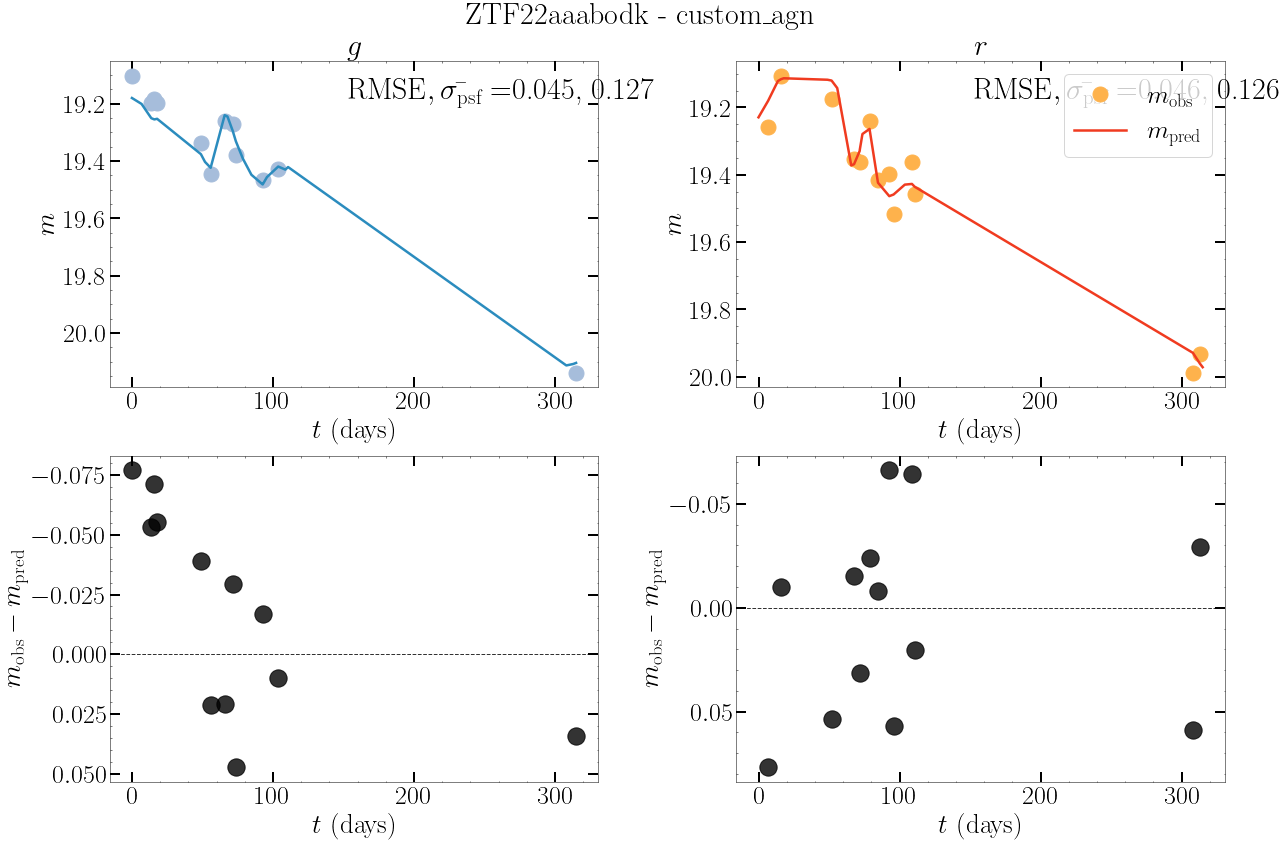

In [42]:
min_datapoints_each_filter = 10
num_to_show = 2

def get_duration_from_normalized_lc_with_key(lc, min_time, max_time):
    lc_unnormalized = unnormalize_time(lc, min_time, max_time)
    return lc_unnormalized.max() - lc_unnormalized.min()

def get_counters_and_keys_from_mode(mode='random'):
    if mode == 'low_N_high_D':
        counters_and_keys = [
            # observed_mask is same as `decoded_lcs_test[key][2]`
            # observed_time is same as `decoded_lcs_test[key][3]`
            (counter, key) for counter, key in enumerate(decoded_lcs_test.keys()) \
            if (np.all(decoded_lcs_test[key][2].sum(0) < min_datapoints_each_filter)) \
            and (
                get_duration_from_normalized_lc_with_key(
                    decoded_lcs_test[key][3], min_time, max_time
                ) >= np.median(duration_lcs)
            )
        ]
    elif mode == 'low_N_low_D':
        counters_and_keys = [
            # observed_mask is same as `decoded_lcs_test[key][2]`
            # observed_time is same as `decoded_lcs_test[key][3]`
            (counter, key) for counter, key in enumerate(decoded_lcs_test.keys()) \
            if (np.all(decoded_lcs_test[key][2].sum(0) < min_datapoints_each_filter)) \
            and (
                get_duration_from_normalized_lc_with_key(
                    decoded_lcs_test[key][3], min_time, max_time
                ) < np.median(duration_lcs)
            )
        ]
    elif mode == 'high_N_high_D':
        counters_and_keys = [
            # observed_mask is same as `decoded_lcs_test[key][2]`
            # observed_time is same as `decoded_lcs_test[key][3]`
            (counter, key) for counter, key in enumerate(decoded_lcs_test.keys()) \
            if (np.all(decoded_lcs_test[key][2].sum(0) >= min_datapoints_each_filter)) \
            and (
                get_duration_from_normalized_lc_with_key(
                    decoded_lcs_test[key][3], min_time, max_time
                ) >= np.median(duration_lcs)
            )
        ]
    elif mode == 'high_N_low_D':
        counters_and_keys = [
            # observed_mask is same as `decoded_lcs_test[key][2]`
            # observed_time is same as `decoded_lcs_test[key][3]`
            (counter, key) for counter, key in enumerate(decoded_lcs_test.keys()) \
            if (np.all(decoded_lcs_test[key][2].sum(0) >= min_datapoints_each_filter)) \
            and (
                get_duration_from_normalized_lc_with_key(
                    decoded_lcs_test[key][3], min_time, max_time
                ) < np.median(duration_lcs)
            )    
        ]
    elif mode == 'random':
        counters_and_keys = [
            # observed_mask is same as `decoded_lcs_test[key][2]`
            # observed_time is same as `decoded_lcs_test[key][3]`
            (counter, key) for counter, key in enumerate(decoded_lcs_test.keys())
        ]

    return counters_and_keys

modes = [
    'random', 'low_N_high_D', 'low_N_low_D',
    'high_N_high_D', 'high_N_low_D'
]
for mode in modes:
    counters_and_keys = get_counters_and_keys_from_mode(mode)
    show_counter = 0
    print(f'Total {len(counters_and_keys)} examples with mode = "{mode}"')

    for counter, key in counters_and_keys:
        test_currObjId = test_objIds_dataloader[counter]
        test_currObjId_index = np.where(total_objIds == test_currObjId)
        test_currCommonFinkclass = total_common_finkclasses[test_currObjId_index].squeeze()
        test_currCommonFinkclass = test_currCommonFinkclass[test_currCommonFinkclass != '0']
        assert len(test_currCommonFinkclass) == 1

        # Also, we pass the same min_max_mags even if we use local normalization
        # for the mags because in plot_decoded_lc, we select the min/max for
        # that light curve, so it takes care of that.

        # Plot test decoded lc
        _ = plot_decoded_lc(
            decoded_lcs_test, key=key, objId=test_currObjId,
            unnormalize_lcs=True, min_time=min_time, max_time=max_time,
            min_max_mags=min_max_mags, prob_plot=False,
            whichclass=test_currCommonFinkclass[0],
            also_show_sigmapsf=True
        )
        plt.show()
        plt.close()

        if show_counter == num_to_show:
            break

        show_counter += 1

# Interpretation of encoder attention scores

In [43]:
from evaluate_unsupervised import (
    dim, latent_dim, rec_hidden, sample_tp,
    embed_time, learn_emb, enc_num_heads, device,
    model_file_path, DATA_COMBINED_PATH,
    DATA_IDS_PATH, ref_resolution_days
)
from models import enc_mtan_rnn, dec_mtan_rnn

In [44]:
import torch
rec = enc_mtan_rnn(
    dim, latent_dim, rec_hidden,
    embed_time=embed_time, learn_emb=learn_emb,
    num_heads=enc_num_heads, device=device
).to(device)

model_file = torch.load(model_file_path, map_location=torch.device('cpu'))
rec.load_state_dict(model_file['rec_state_dict'])
rec.eval()

rec

enc_mtan_rnn(
  (att): multiTimeAttention(
    (linears): ModuleList(
      (0-1): 2 x Linear(in_features=128, out_features=128, bias=True)
      (2): Linear(in_features=4, out_features=64, bias=True)
    )
  )
  (gru_rnn): GRU(64, 64, batch_first=True, bidirectional=True)
  (hiddens_to_z0): Sequential(
    (0): Linear(in_features=128, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=4, bias=True)
  )
  (periodic): Linear(in_features=1, out_features=127, bias=True)
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

See [these lines in the original mTAN code](https://github.com/reml-lab/mTAN/blob/7a3d536ee742f1cacb4a6d3478ac78a228d995ff/src/models.py#L109). W0e first calculate the key and query, followed by mTAN to calculate the attention, which is then passed to a GRU and then a hidden linear layer module.

In [45]:
import torch
# import numpy as np
# from torch.utils.data import DataLoader
# from prepare_data import MyDataSet

# data_combined = torch.load(DATA_COMBINED_PATH)
# data_Ids = np.load(DATA_IDS_PATH)
# dataset = MyDataSet(data_combined, data_Ids)
# test_loader = DataLoader(dataset, batch_size=1, num_workers=1, shuffle=False)

test_loader = torch.load('test_dataloader.pth')
decoded_lcs_test = np.load('evaluate_test_decoded_lcs.npz')
test_objIds_dataloader = np.load('evaluate_test_objIds_dataloader.npy')

/home/ygondhal/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


(347,) (1, 347, 2) (1, 347, 2) (1, 247)


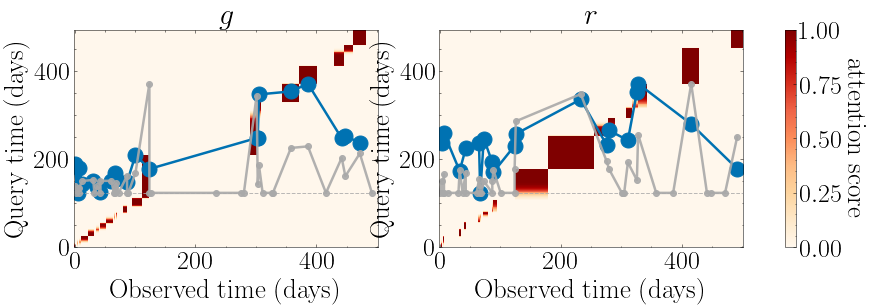

(347,) (1, 347, 2) (1, 347, 2) (1, 85)


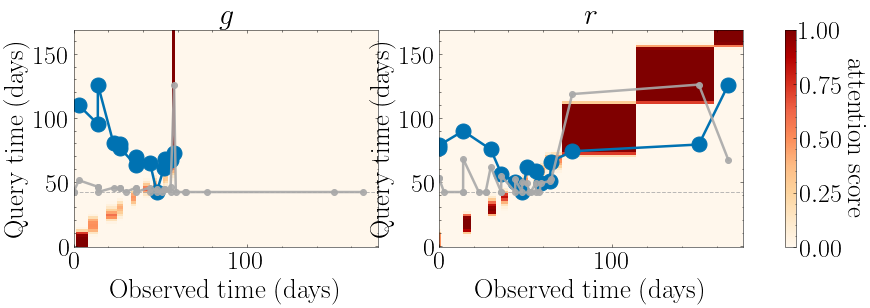

(347,) (1, 347, 2) (1, 347, 2) (1, 9)


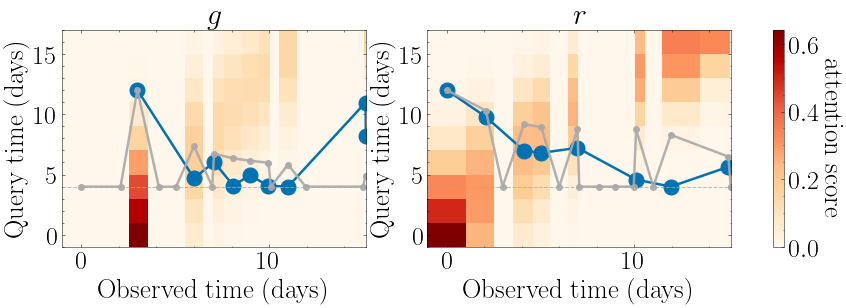

(347,) (1, 347, 2) (1, 347, 2) (1, 133)


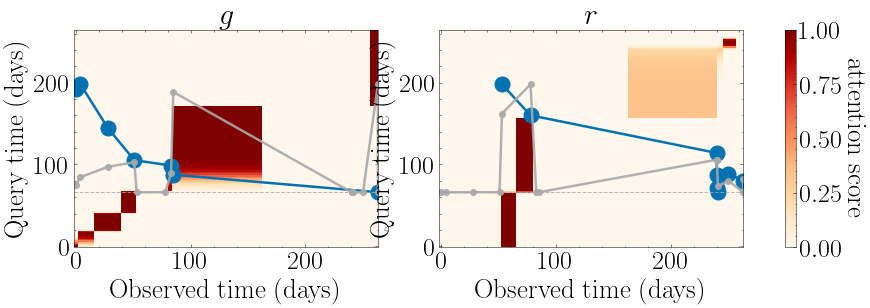

(347,) (1, 347, 2) (1, 347, 2) (1, 271)


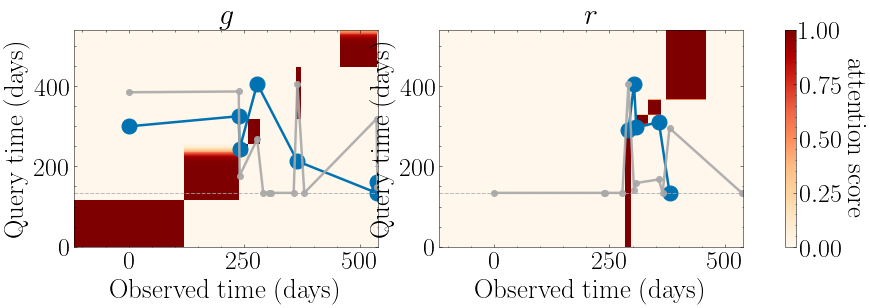

(347,) (1, 347, 2) (1, 347, 2) (1, 45)


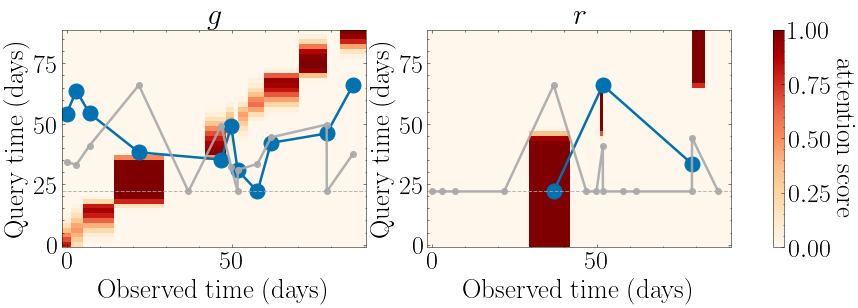

(347,) (1, 347, 2) (1, 347, 2) (1, 8)


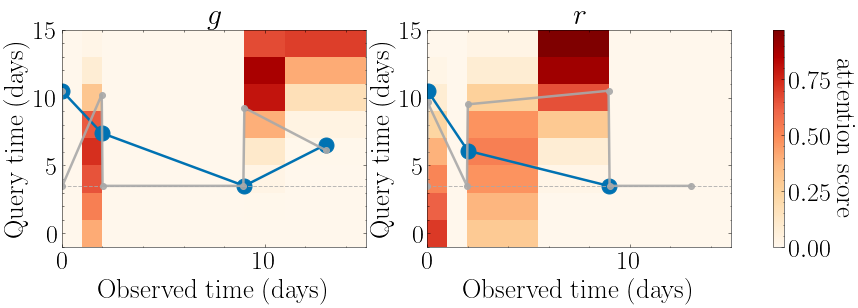

(347,) (1, 347, 2) (1, 347, 2) (1, 207)


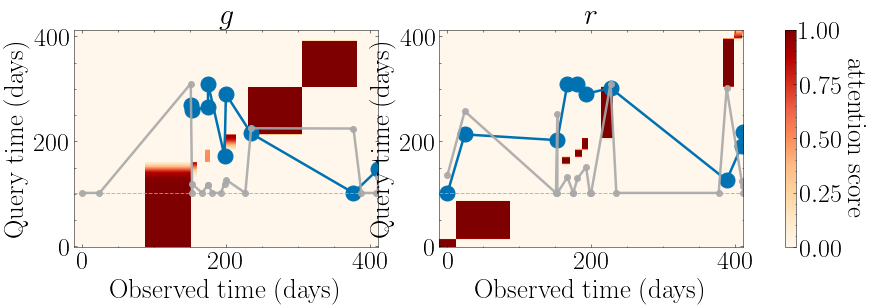

In [46]:
import utils

from torch_intermediate_layer_getter import IntermediateLayerGetter as MidGetter
return_layers = {
    'att': 'att'
#     'hiddens_to_z0': 'hiddens_to_z0',
}
mid_getter = MidGetter(rec, return_layers=return_layers, keep_output=True)

from matplotlib.ticker import FormatStrFormatter

def _normalize_line_plot(y, a=0., b=1.):
    norm = (y - y.min()) / (y.max() - y.min())
    scaled = a + norm * (b - a)
    return scaled

train_min_max_times = np.load('train_min_max_times.npy')
min_time, max_time = train_min_max_times[0], train_min_max_times[1]

#################################### NOTE #####################################
# The below code is partly a copy-paste of the code in evaluate_unsupervised.py
# NOTE: The below code for visualization assumes a batch size of 1.
# Otherwise it will give an error or not work as expected.
###############################################################################

train_val_test_min_max_times_filename = 'train_val_test_min_max_times.npy'
train_val_test_min_max_times = np.load(train_val_test_min_max_times_filename)
train_max_time = train_val_test_min_max_times[1]
delta_t = (ref_resolution_days * 24) / train_max_time

objectId_column, fid_column = 'objectId', 'fid'

with torch.no_grad():
    for c, batch in enumerate(test_loader):
        objId = batch[1][0]
        key = list(decoded_lcs_test.keys())[int(np.where(test_objIds == objId)[0])]

        test_batch = batch[0]
        test_batch = test_batch.to(device)
        observed_data, observed_mask, observed_tp = (
            test_batch[:, :, :dim],
            test_batch[:, :, dim: 2 * dim],
            test_batch[:, :, -1],
        )
        if sample_tp and sample_tp < 1:
            subsampled_data, subsampled_tp, subsampled_mask = subsample_timepoints(
                observed_data.clone(), observed_tp.clone(), observed_mask.clone(), sample_tp)
        else:
            subsampled_data, subsampled_tp, subsampled_mask = \
                observed_data, observed_tp, observed_mask

        if sample_tp == 1.:
            assert torch.all(observed_tp == subsampled_tp)

        # Thq query times
        query = utils.generate_query_matrix(subsampled_tp, delta_t, padding_value=-999)

        mid_outputs, model_output = mid_getter(
            torch.cat(
                (subsampled_data, subsampled_mask), 2
            ),
            subsampled_tp, query, return_att=True
        )
        # Shape of mid_outputs['att'][1] for the encoder is (B, h, Tq, Tk, 2*num_filters)
#         print(mid_outputs['att'][0].shape, mid_outputs['att'][1].shape)
#         print(subsampled_data.shape, subsampled_mask.shape, subsampled_tp.shape)
        
        # Convert to numpy
        subsampled_data, subsampled_tp, subsampled_mask = subsampled_data.numpy(), subsampled_tp.numpy(), subsampled_mask.numpy()
        observed_data, observed_tp, observed_mask = observed_data.numpy(), observed_tp.numpy(), observed_mask.numpy()
        query = query.numpy()

        # The query must be evenly spaced by design
        assert np.allclose(
            np.diff(query.squeeze()), np.diff(query.squeeze())[0]
        )

        df_subset = df_alerts[df_alerts[objectId_column] == objId].compute()

        num_filters = 2
        for i in range(num_filters):
            maskFilt = df_subset[fid_column] == (i+1)
            assert len(df_subset[maskFilt]) == observed_mask[:, :, i].sum()

        # Calculate attention map for plotting
        # First, average over the batch and head dimension.
        attn_map = mid_outputs['att'][1].mean(0).mean(0)
        # `attn_map` contains 2*num_filters entries in the last dimension
        # where first `num_filters` dimensions correspond to the mean and
        # the latter `num_filters` dimensions correspond to standard deviation
        attn_map = attn_map[:, :, :num_filters]

        test_currObjId = test_objIds_dataloader[c]
        test_currObjId_index = np.where(total_objIds == test_currObjId)
        test_currCommonFinkclass = total_common_finkclasses[test_currObjId_index].squeeze()
        test_currCommonFinkclass = test_currCommonFinkclass[test_currCommonFinkclass != '0']
        assert len(test_currCommonFinkclass) == 1

        observed_tp[observed_tp == 0.0] = np.nan
        observed_tp[:, 0] = 0.0
        observed_tp = observed_tp.squeeze()
        tmax = np.nanmax(observed_tp)
        arg_tmax = np.nanargmax(observed_tp)
        assert observed_tp[arg_tmax] == tmax
        observed_data[observed_mask == 0] = np.nan
        row = min_max_mags[np.where(min_max_mags[:, 0] == objId)].squeeze()
        obs_to_show = unnormalize_mag(
            observed_data, observed_mask, float(row[1]), float(row[2])
        )

        print(observed_tp.shape, obs_to_show.shape, observed_mask.shape, query.shape)

        observed_tp_unnormalized = unnormalize_time(
            observed_tp[observed_tp <= tmax].squeeze(), min_time, max_time
        ) / 24
        query_tp_unnormalized = unnormalize_time(
            query.squeeze(), min_time, max_time
        ) / 24
        assert np.allclose(
            np.diff(query_tp_unnormalized.squeeze()),
            np.diff(query_tp_unnormalized.squeeze())[0],
            rtol=1e-3
        )

        X, Y = np.meshgrid(
            observed_tp_unnormalized,
            query_tp_unnormalized
        )

        fig, ax = plt.subplots(1, num_filters, figsize=(15, 4))
        for ii in range(num_filters):
            # arg_tmax_ii = np.nanargmax(
            #    observed_tp[observed_mask.squeeze()[:, ii].astype(bool)]
            # )
            # Only select the relevant region of attention map
            # i.e., only uptil the max time of observation for this light curve
            attn_map_to_show = attn_map[:, :arg_tmax+1, ii]
            pc = ax[ii].pcolormesh(
                X, Y, attn_map_to_show,
                shading='nearest', cmap='OrRd'
            )
            obs_to_show_ii = obs_to_show.squeeze()[:, ii]
            obs_to_show_ii = obs_to_show_ii[~np.isnan(obs_to_show_ii)]

            observed_tp_unnormalized_ii = unnormalize_time(
                observed_tp[observed_mask.squeeze()[:, ii].astype(bool)],
                min_time, max_time
            ) / 24
            assert set(observed_tp_unnormalized_ii).issubset(
                set(observed_tp_unnormalized)
            )

            # Show light curve on top
            ax[ii].plot(
                observed_tp_unnormalized_ii,
                _normalize_line_plot(
                    obs_to_show_ii,
                    a=np.quantile(Y, 0.25), b=np.quantile(Y, 0.75)
                ),
                '-o', label=r'$m_{\mathrm{obs}}$', markersize=15,
                linewidth=2.5, c='#0072B2',
            )
            # Show column averaged attention map
            normalize_attn_map_to_show = _normalize_line_plot(
                    attn_map_to_show.mean(axis=0),
                    a=np.quantile(Y, 0.25), b=np.quantile(Y, 0.75)
                )
            ax[ii].plot(
                observed_tp_unnormalized,
                normalize_attn_map_to_show, '-o',
                linewidth=2.5, c='darkgray', alpha=0.9
            )
            ax[ii].axhline(
                y=normalize_attn_map_to_show.min(),
                linestyle='--', c='darkgray', alpha=0.8
            )

            ax[ii].set_xlabel('Observed time (days)', fontsize=axeslabelsize)
            ax[ii].set_ylabel('Query time (days)', fontsize=axeslabelsize)
            ax[ii].tick_params(axis='x', labelsize=ticklabelsize)
            ax[ii].tick_params(axis='y', labelsize=ticklabelsize)
            if ii == 0:
                ax[ii].set_title(r'$g$', fontsize=titlesize)
            elif ii == 1:
                ax[ii].set_title(r'$r$', fontsize=titlesize)

            # Plot query points as horizontal lines to give an idea
            # of the no. of query points and spacing between adjacent
            # query points.
#             for y in query_tp_unnormalized:
#                 ax[ii].axhline(y=y, linestyle='dashed', alpha=0.2, c='gray')

        cbar = fig.colorbar(pc, ax=ax.ravel().tolist())
        cbar.set_label(
            'attention score', rotation=270,
            labelpad=25, fontsize=axeslabelsize
        )
        cbar.ax.tick_params(labelsize=ticklabelsize)

        plt.show()

        if c == 7:
            break